Running: geom=triangle_R0 (preserve_zero) | n=2 | H=32
Running: geom=triangle_R0 (preserve_zero) | n=2 | H=64
Running: geom=triangle_R0 (preserve_zero) | n=2 | H=128
Running: geom=triangle_R0 (preserve_zero) | n=3 | H=32
Running: geom=triangle_R0 (preserve_zero) | n=3 | H=64
Running: geom=triangle_R0 (preserve_zero) | n=3 | H=128
Running: geom=triangle_R0 (preserve_zero) | n=4 | H=32
Running: geom=triangle_R0 (preserve_zero) | n=4 | H=64
Running: geom=triangle_R0 (preserve_zero) | n=4 | H=128
Running: geom=triangle_R0 rotated 90deg (preserve_zero) | n=2 | H=32
Running: geom=triangle_R0 rotated 90deg (preserve_zero) | n=2 | H=64
Running: geom=triangle_R0 rotated 90deg (preserve_zero) | n=2 | H=128
Running: geom=triangle_R0 rotated 90deg (preserve_zero) | n=3 | H=32
Running: geom=triangle_R0 rotated 90deg (preserve_zero) | n=3 | H=64
Running: geom=triangle_R0 rotated 90deg (preserve_zero) | n=3 | H=128
Running: geom=triangle_R0 rotated 90deg (preserve_zero) | n=4 | H=32
Running: geom=tri

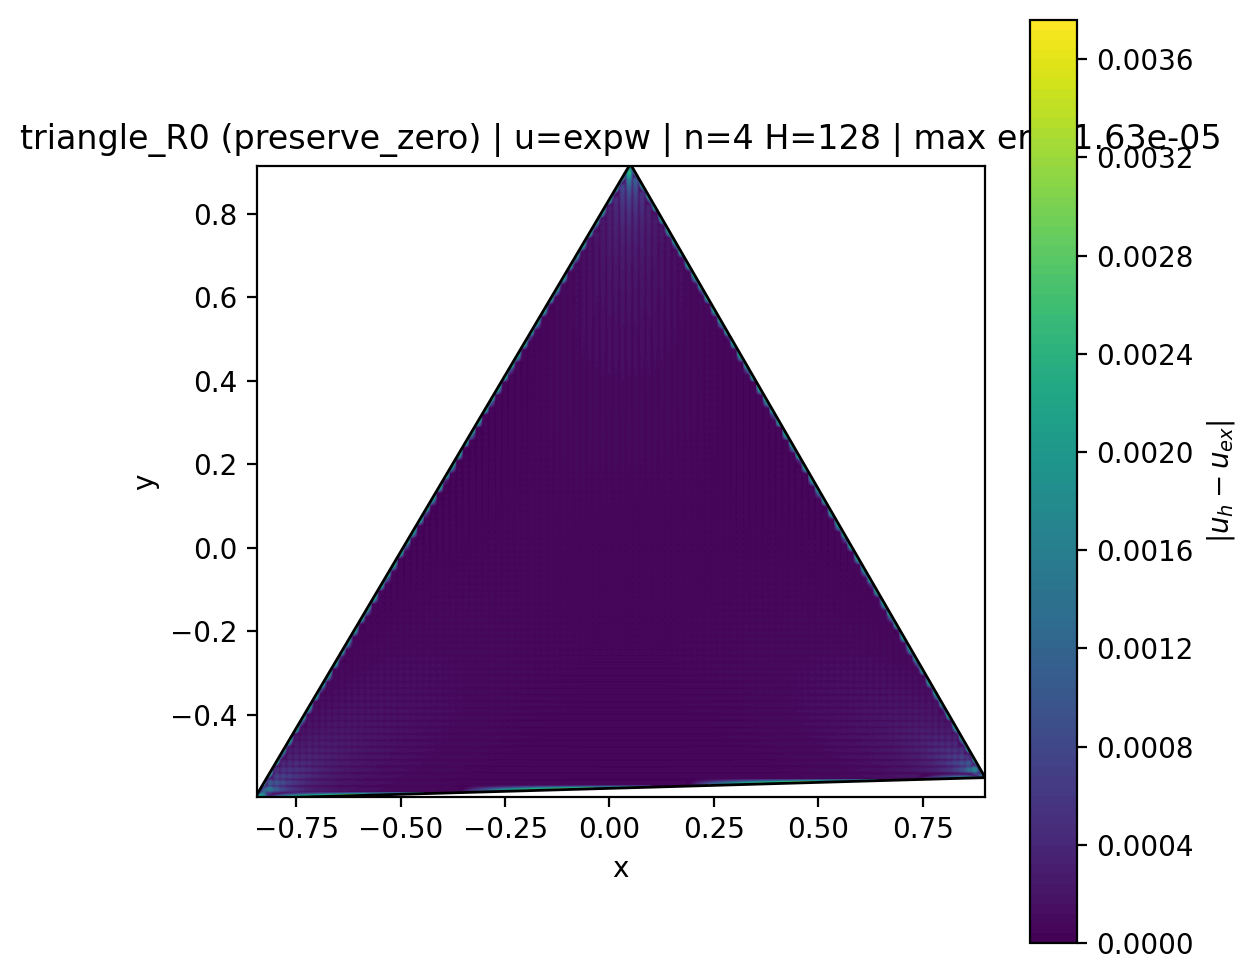

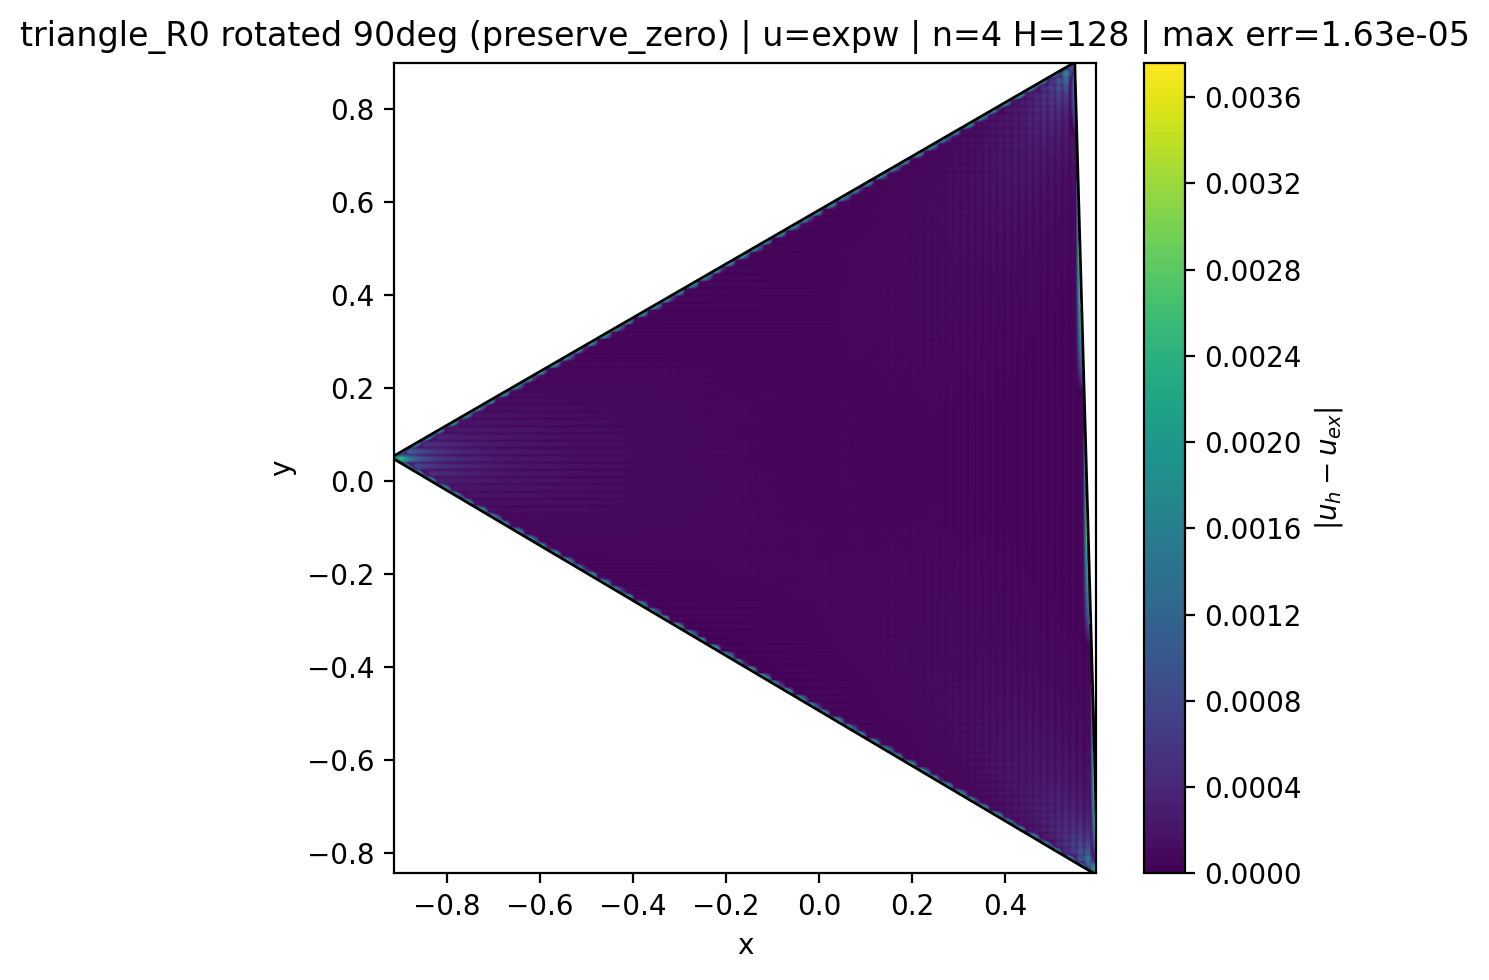

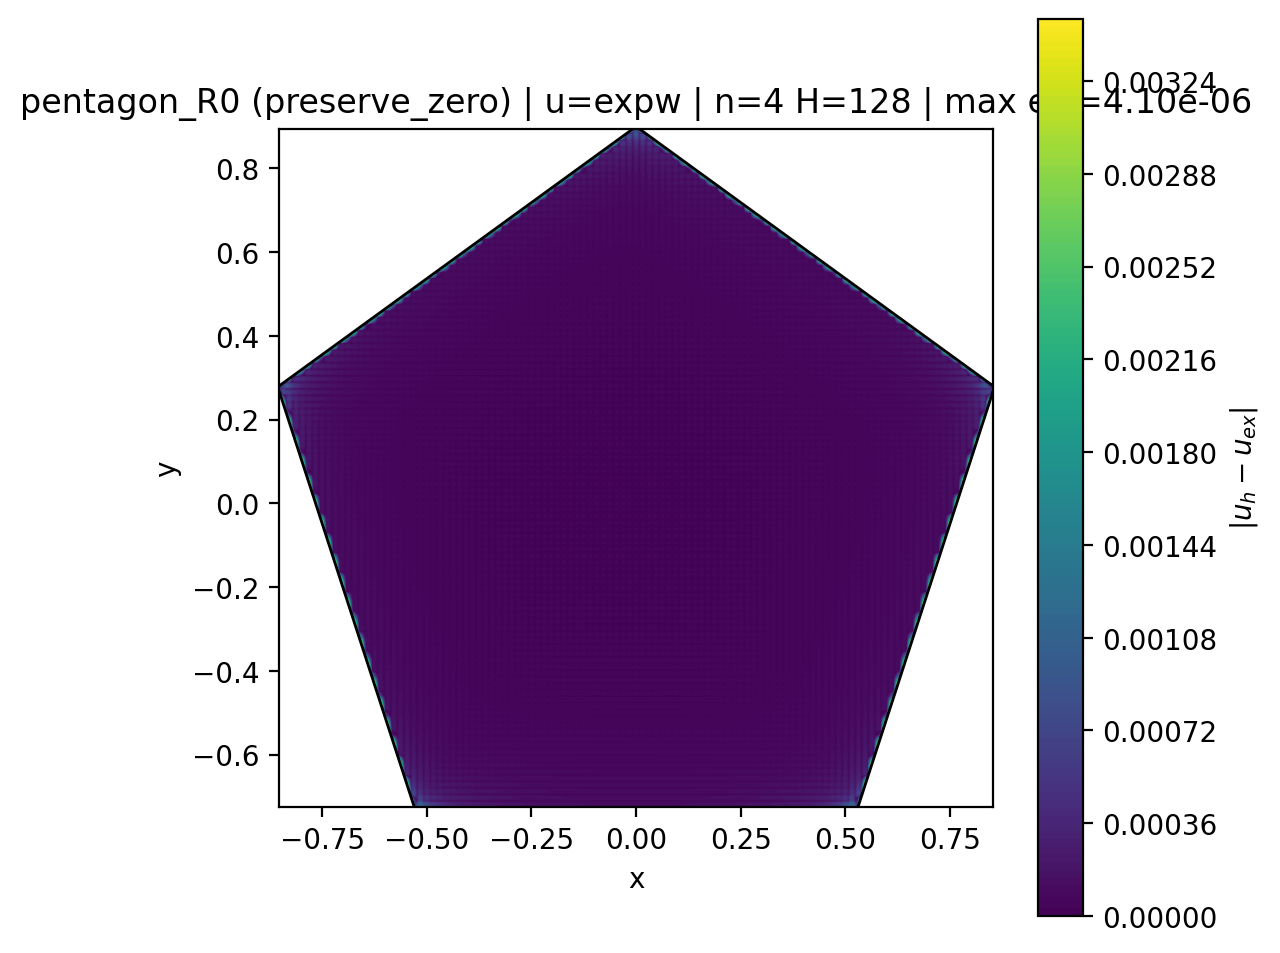

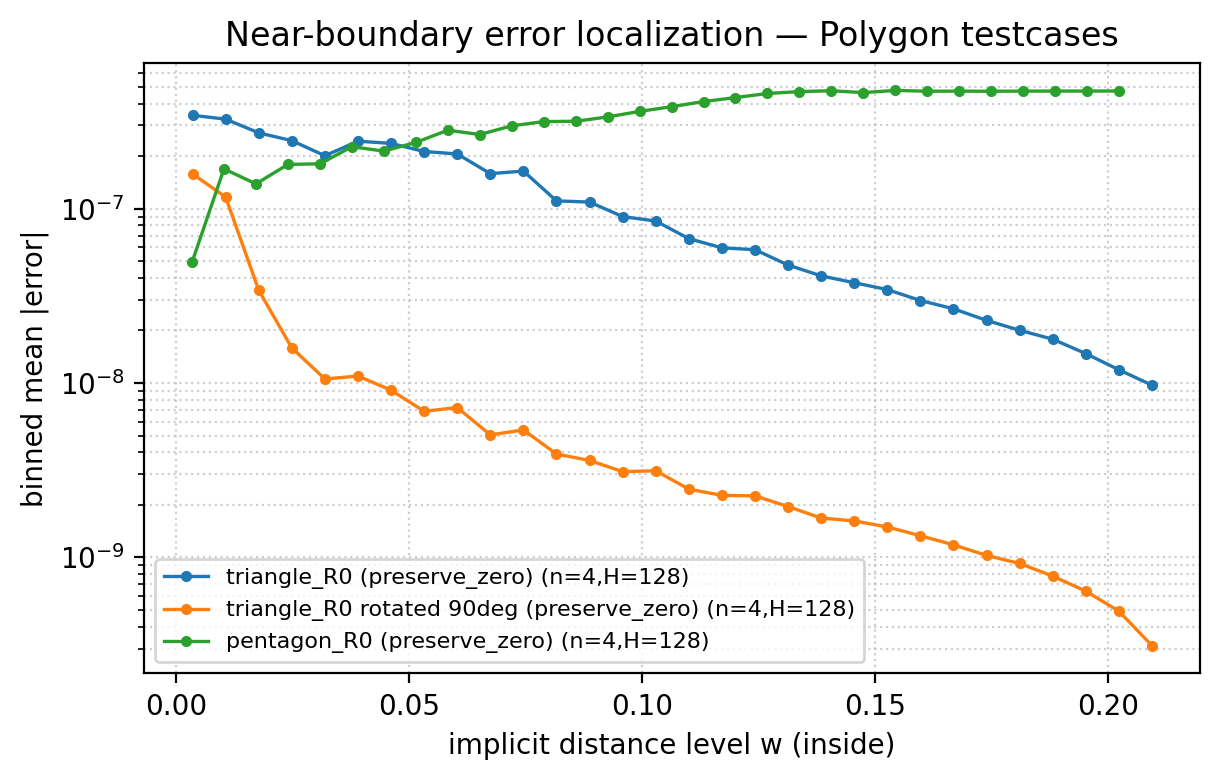

Max error (inside Ω):


n                                                 2                      \
H                                               32        64        128   
geom                                                                      
pentagon_R0 (preserve_zero)                0.000052  0.000019  0.000005   
triangle_R0 (preserve_zero)                0.000638  0.000014  0.000008   
triangle_R0 rotated 90deg (preserve_zero)  0.000638  0.000014  0.000009   

n                                                 3                      \
H                                               32        64        128   
geom                                                                      
pentagon_R0 (preserve_zero)                0.000086  0.000045  0.000007   
triangle_R0 (preserve_zero)                0.000530  0.000029  0.000005   
triangle_R0 rotated 90deg (preserve_zero)  0.000809  0.000031  0.000005   

n                                                 4                      
H                                               32        64        128  
geom                                                                     
pentagon_R0 (preserve_zero)                0.000030  0.000012  0.000004  
triangle_R0 (preserve_zero)                0.008110  0.000017  0.000016  
triangle_R0 rotated 90deg (preserve_zero)  0.009068  0.000016  0.000016

Mean error (inside Ω):


n                                                 2                          \
H                                               32        64            128   
geom                                                                          
pentagon_R0 (preserve_zero)                0.000026  0.000010  3.019579e-06   
triangle_R0 (preserve_zero)                0.000016  0.000002  4.106997e-07   
triangle_R0 rotated 90deg (preserve_zero)  0.000016  0.000001  4.123247e-07   

n                                                 3                          \
H                                               32        64            128   
geom                                                                          
pentagon_R0 (preserve_zero)                0.000041  0.000009  2.064082e-06   
triangle_R0 (preserve_zero)                0.000015  0.000002  4.567434e-07   
triangle_R0 rotated 90deg (preserve_zero)  0.000024  0.000002  4.569823e-07   

n                                                 4                \
H                                               32            64    
geom                                                                
pentagon_R0 (preserve_zero)                0.000009  7.172362e-07   
triangle_R0 (preserve_zero)                0.000115  2.125535e-07   
triangle_R0 rotated 90deg (preserve_zero)  0.000129  1.282468e-07   

n                                                        
H                                                   128  
geom                                                     
pentagon_R0 (preserve_zero)                3.762484e-07  
triangle_R0 (preserve_zero)                1.117995e-07  
triangle_R0 rotated 90deg (preserve_zero)  1.240424e-08

In [2]:
# %% [markdown]
# # Local error distribution study (Collocation)
#
# This notebook mirrors the *local error distribution* workflow used for the FEM/WEB study,
# but uses the WEB-spline **collocation** solver (`collocation_WEB.collocation_2d`).
#
# Key differences vs FEM/WEB weak form:
# - There is **no** `MAX_SUBDIVISION` in collocation.
# - For some geometries we compare **multiple implicit/weight functions** for the same shape
#   (e.g. circle: “distance-like” vs smooth polynomial; L-shape: R-function variants).
#
# We solve manufactured problems of the form:
# - Domain: $\Omega = \{ (x,y): w(x,y) > 0 \}$
# - PDE: $-\Delta u = f$ in $\Omega$, with $u=0$ on $\partial\Omega$
#
# Important numerical note:
# - The collocation operator uses $w, w_x, w_y, w_{xx}, w_{yy}$. If the weight is not sufficiently
#   smooth (e.g. a raw Euclidean distance with a cusp), accuracy can degrade badly. For that reason,
#   we include a *regularized* distance-like circle variant.

# %%
import os
import sys
from dataclasses import dataclass
from typing import Callable, Dict, Optional, Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

# Optional: used only for higher-resolution plotting (upsampling)
try:
    from scipy.interpolate import RectBivariateSpline
except Exception:
    RectBivariateSpline = None

# Allow importing modules from the "Neural Analysis" folder (not a Python package).
NA_DIR = os.path.join(os.getcwd(), "Neural Analysis")
if NA_DIR not in sys.path:
    sys.path.insert(0, NA_DIR)

import collocation_WEB as colloc
import Geomertry as geom

# Ensure the latest geometry code is used (handy while iterating).
import importlib
importlib.reload(geom)

plt.rcParams.update({"figure.dpi": 200})

# %%
# Reproducibility
np.random.seed(0)
torch.manual_seed(0)

# Toggle for quick validation runs
SMOKE = False

# Manufactured solution type.
# - "expw": u = exp(w) - 1  (non-polynomial; usually more informative)
# - "w2":   u = w^2         (can be near-exact for polynomial weights)
U_EXACT_TYPE = "expw"

# Heatmap plotting resolution improvements:
# - We upsample the solution grid for smoother contourf plots (purely for visualization).
# - We recompute u_ex and w on the upsampled grid so the mask and error cover Ω cleanly.
# - This does NOT change the numerical solution, only how we render it.
PLOT_UPSAMPLE = 4 if not SMOKE else 3
CONTOUR_LEVELS = 120

# Plot coverage behavior:
# - If True: plot the full rectangular *physical* domain used for the PDE (e.g. [-1,1]^2 or [0,1]^2)
#            so the contourf fully fills the plotting area.
# - If False: crop and mask to the implicit domain Ω (w>0).
PLOT_FULL_PHYSICAL_DOMAIN = False

# When not plotting full physical domain, crop tightly to Ω.
ZOOM_TO_DOMAIN = not PLOT_FULL_PHYSICAL_DOMAIN
ZOOM_PAD_FRAC = 0 #!0.01

# %%
def zero_fn(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    return np.zeros_like(np.asarray(x, dtype=np.float64))


@dataclass(frozen=True)
class GeometryVariant:
    name: str
    model: torch.nn.Module
    domain: Optional[Dict[str, float]]  # physical coords for PDE; if None, physical=[0,1]^2


class CircleDistanceRegularized(torch.nn.Module):
    """Regularized distance-like weight for the unit circle on [-1,1]^2.

    We use:
        w(x,y) = 1 - sqrt(x^2 + y^2 + eps) / sqrt(1 + eps)

    so that:
    - w(1,0)=w(0,1)=0 (boundary preserved)
    - w is smooth everywhere (no singular second derivatives at the origin)

    eps controls smoothing near the origin.
    """

    def __init__(self, eps: float = 1e-2):
        super().__init__()
        self.eps = float(eps)

    def forward(self, crd: torch.Tensor) -> torch.Tensor:
        x = crd[..., 0]
        y = crd[..., 1]
        r = torch.sqrt(x * x + y * y + self.eps)
        r1 = float(np.sqrt(1.0 + self.eps))
        return 1.0 - r / r1


def make_manufactured_problem(
    model: torch.nn.Module,
    u_type: str = "expw",
) -> Tuple[
    Callable[[np.ndarray, np.ndarray], np.ndarray],
    Callable[[np.ndarray, np.ndarray], np.ndarray],
    colloc.NeuralWeightFunction,
    ]:
    """Manufactured solution u_ex(w) with homogeneous Dirichlet on w=0.

    Returns f_phys, u_exact_phys, wfct_phys where derivatives are w.r.t the input coordinates.

    u_type:
      - "w2":   u = w^2,        f = -Δu = -[2|∇w|^2 + 2w Δw]
      - "expw": u = exp(w)-1,   f = -Δu = -exp(w)[|∇w|^2 + Δw]
    """
    wfct_phys = colloc.NeuralWeightFunction(model, domain=None, transform=None)

    if u_type == "w2":

        def u_exact_phys(xp: np.ndarray, yp: np.ndarray) -> np.ndarray:
            w, *_ = wfct_phys(xp, yp)
            return w**2

        def f_phys(xp: np.ndarray, yp: np.ndarray) -> np.ndarray:
            w, wx, wy, wxx, wyy = wfct_phys(xp, yp)
            lap_u = 2.0 * (wx**2 + wy**2) + 2.0 * w * (wxx + wyy)
            return -lap_u

    elif u_type == "expw":

        def u_exact_phys(xp: np.ndarray, yp: np.ndarray) -> np.ndarray:
            w, *_ = wfct_phys(xp, yp)
            return np.exp(w) - 1.0

        def f_phys(xp: np.ndarray, yp: np.ndarray) -> np.ndarray:
            w, wx, wy, wxx, wyy = wfct_phys(xp, yp)
            lap_u = np.exp(w) * (wx**2 + wy**2 + wxx + wyy)
            return -lap_u

    else:
        raise ValueError(f"Unknown U_EXACT_TYPE={u_type!r}. Use 'expw' or 'w2'.")

    return f_phys, u_exact_phys, wfct_phys


def transform_grid_to_physical(
    xg: np.ndarray,
    yg: np.ndarray,
    domain: Optional[Dict[str, float]],
) -> Tuple[np.ndarray, np.ndarray]:
    if domain is None:
        return np.asarray(xg, dtype=np.float64), np.asarray(yg, dtype=np.float64)
    sx = domain["x2"] - domain["x1"]
    sy = domain["y2"] - domain["y1"]
    xp = domain["x1"] + np.asarray(xg, dtype=np.float64) * sx
    yp = domain["y1"] + np.asarray(yg, dtype=np.float64) * sy
    return xp, yp


def compute_near_boundary_binning(
    w_inside: np.ndarray,
    err_inside: np.ndarray,
    n_bins: int = 30,
    w_max: Optional[float] = None,
) -> pd.DataFrame:
    w_inside = np.asarray(w_inside, dtype=np.float64).ravel()
    err_inside = np.asarray(err_inside, dtype=np.float64).ravel()

    mask = np.isfinite(w_inside) & np.isfinite(err_inside)
    w_inside = w_inside[mask]
    err_inside = err_inside[mask]

    if w_inside.size == 0:
        return pd.DataFrame({"w_mid": [], "err_mean": [], "count": []})

    if w_max is None:
        w_max = float(np.quantile(w_inside, 0.995))

    w_max = max(w_max, 1e-12)
    edges = np.linspace(0.0, w_max, n_bins + 1)

    rows = []
    for i in range(n_bins):
        a, b = edges[i], edges[i + 1]
        sel = (w_inside >= a) & (w_inside < b)
        if not np.any(sel):
            continue
        rows.append(
            {
                "w_mid": 0.5 * (a + b),
                "err_mean": float(np.mean(err_inside[sel])),
                "count": int(np.sum(sel)),
            }
        )

    return pd.DataFrame(rows)


def _upsample_tensor_grid(
    xP: np.ndarray,
    yP: np.ndarray,
    field: np.ndarray,
    factor: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Upsample a field defined on a tensor-product grid for prettier contourf plots.

    Handles both meshgrid conventions (indexing='xy' and indexing='ij') by detecting
    which axis x/y vary along.
    """
    if factor <= 1:
        return xP, yP, field
    if RectBivariateSpline is None:
        # SciPy not available; fall back to original grid
        return xP, yP, field

    xP = np.asarray(xP, dtype=np.float64)
    yP = np.asarray(yP, dtype=np.float64)
    z = np.asarray(field, dtype=np.float64)

    x_row = xP[0, :]
    x_col = xP[:, 0]
    y_row = yP[0, :]
    y_col = yP[:, 0]

    # Determine which axis corresponds to x variation
    x_row_unique = np.unique(np.round(x_row, 12)).size
    x_col_unique = np.unique(np.round(x_col, 12)).size
    x_var_axis = 1 if x_row_unique > x_col_unique else 0

    if x_var_axis == 1:
        # x varies along columns; y varies along rows
        x1d = x_row
        y1d = y_col
        z2d = z
    else:
        # x varies along rows; y varies along columns
        x1d = x_col
        y1d = y_row
        z2d = z.T

    # Ensure strictly increasing axes for spline evaluation
    x1d = np.asarray(x1d, dtype=np.float64)
    y1d = np.asarray(y1d, dtype=np.float64)

    if x1d[0] > x1d[-1]:
        x1d = x1d[::-1]
        z2d = z2d[:, ::-1]
    if y1d[0] > y1d[-1]:
        y1d = y1d[::-1]
        z2d = z2d[::-1, :]

    # If there are any duplicates (can happen due to roundoff), fall back safely
    if not (np.all(np.diff(x1d) > 0) and np.all(np.diff(y1d) > 0)):
        return xP, yP, field

    x_fine = np.linspace(float(x1d[0]), float(x1d[-1]), x1d.size * factor)
    y_fine = np.linspace(float(y1d[0]), float(y1d[-1]), y1d.size * factor)

    spl = RectBivariateSpline(y1d, x1d, z2d, kx=1, ky=1)
    z_fine = spl(y_fine, x_fine)
    xP_f, yP_f = np.meshgrid(x_fine, y_fine)
    return xP_f, yP_f, z_fine


def _zoom_axes_to_domain(ax, x: np.ndarray, y: np.ndarray, inside: np.ndarray, pad_frac: Optional[float] = None):
    if not ZOOM_TO_DOMAIN:
        return
    if pad_frac is None:
        pad_frac = float(ZOOM_PAD_FRAC)
    try:
        xi = np.asarray(x)[inside]
        yi = np.asarray(y)[inside]
        if xi.size < 10:
            return
        xmin, xmax = float(np.min(xi)), float(np.max(xi))
        ymin, ymax = float(np.min(yi)), float(np.max(yi))
        dx = max(xmax - xmin, 1e-12)
        dy = max(ymax - ymin, 1e-12)
        ax.set_xlim(xmin - pad_frac * dx, xmax + pad_frac * dx)
        ax.set_ylim(ymin - pad_frac * dy, ymax + pad_frac * dy)
    except Exception:
        return


# %%
# Geometry variants: each provides a torch model w(x,y) with w>0 inside.
#
# NOTE: Reduced to polygon testcases only (triangles + pentagon).

DOMAIN_M11 = {"x1": -1.0, "x2": 1.0, "y1": -1.0, "y2": 1.0}

# Base triangle vertices used by geom.AnaliticalDistanceTriangle_RFunction defaults
TRI_VERTS = np.array([[-0.85, -0.60], [0.90, -0.55], [0.05, 0.92]], dtype=np.float64)
TRI_VERTS_R90 = TRI_VERTS @ np.array([[0.0, -1.0], [1.0, 0.0]], dtype=np.float64).T

GEOMS: List[GeometryVariant] = [
    GeometryVariant(
        name="triangle_R0 (preserve_zero)",
        model=geom.AnaliticalDistanceTriangle_RFunction(smoothness=0.1, preserve_zero_line=True),
        domain=DOMAIN_M11,
    ),
    GeometryVariant(
        name="triangle_R0 rotated 90deg (preserve_zero)",
        model=geom.AnaliticalDistanceTriangle_RFunction(
            smoothness=0.1, preserve_zero_line=True, vertices=TRI_VERTS_R90
        ),
        domain=DOMAIN_M11,
    ),
    GeometryVariant(
        name="pentagon_R0 (preserve_zero)",
        model=geom.AnaliticalDistancePentagon_RFunction(smoothness=0.1, preserve_zero_line=True),
        domain=DOMAIN_M11,
    ),
]

# Sweep parameters
if SMOKE:
    DEGREES = [2, 3]
    HS = [16, 24]
else:
    DEGREES = [2, 3, 4]
    HS = [32, 64, 128]

# %%
def run_one(
    geom_variant: GeometryVariant,
    n: int,
    H: int,
    CD_cache: Dict[int, Dict],
    verbose: bool = False,
):
    """Run collocation and return a result dict with fields for plotting + summary."""

    # Manufactured problem in *physical* coordinates.
    f_phys, u_exact_phys, wfct_phys = make_manufactured_problem(
        geom_variant.model,
        u_type=U_EXACT_TYPE,
    )

    # Weight function for collocation: needs derivatives in *grid* coords.
    # NeuralWeightFunction(domain=...) maps x_grid->x_phys before model eval, and scales derivatives.
    wfct_grid = colloc.NeuralWeightFunction(geom_variant.model, domain=geom_variant.domain, transform=None)

    if n not in CD_cache:
        CD_cache[n] = colloc.compute_collocation_data(n, J_MAX=16)

    Uxy, xB, yB, con, dim_sys, rtimes = colloc.collocation_2d(
        n=n,
        H=H,
        wfct=wfct_grid,
        f=f_phys,
        CD=CD_cache[n],
        verbose=verbose,
        domain=geom_variant.domain,
        solve_method="auto",
        dense_threshold=2000,
        g=zero_fn,
        gx=zero_fn,
        gy=zero_fn,
        gxx=zero_fn,
        gyy=zero_fn,
    )

    # Transform collocation grid to physical coordinates for error evaluation.
    xP, yP = transform_grid_to_physical(xB, yB, geom_variant.domain)

    # Evaluate w and u_exact in physical coordinates (on the collocation grid).
    wP, *_ = wfct_phys(xP, yP)
    uex = u_exact_phys(xP, yP)

    err = np.abs(Uxy - uex)
    inside = wP > 0

    err_inside = err[inside]
    w_inside = wP[inside]

    summary = {
        "geom": geom_variant.name,
        "u_exact": U_EXACT_TYPE,
        "n": int(n),
        "H": int(H),
        "dim_sys": int(dim_sys),
        "con": float(con) if con is not None else np.nan,
        "t_sys": float(rtimes.get("sys", np.nan)),
        "t_ext": float(rtimes.get("ext", np.nan)),
        "t_sol": float(rtimes.get("sol", np.nan)),
        "t_total": float(rtimes.get("total", np.nan)),
        "err_mean": float(np.mean(err_inside)) if err_inside.size else np.nan,
        "err_max": float(np.max(err_inside)) if err_inside.size else np.nan,
        "inside_count": int(err_inside.size),
    }

    bins = compute_near_boundary_binning(w_inside=w_inside, err_inside=err_inside, n_bins=30)

    return {
        "summary": summary,
        "Uxy": Uxy,
        "xP": xP,
        "yP": yP,
        "wP": wP,
        "err": err,
        "inside": inside,
        "bins": bins,
        # Keep the manufactured functions so plotting can recompute (u_ex, w) on a finer grid
        "u_exact_phys": u_exact_phys,
        "wfct_phys": wfct_phys,
    }


# %%
def plot_error_field(res, title: str):
    xP, yP, Uxy = res["xP"], res["yP"], res["Uxy"]
    u_exact_phys = res["u_exact_phys"]
    wfct_phys = res["wfct_phys"]

    # Upsample u_h for smoother contourf visualization
    xPu, yPu, Uh_u = _upsample_tensor_grid(xP, yP, Uxy, factor=int(PLOT_UPSAMPLE))

    # Recompute u_ex and w on the upsampled grid so the mask fills Ω cleanly
    w_u, *_ = wfct_phys(xPu, yPu)
    Uex_u = u_exact_phys(xPu, yPu)
    err_u = np.abs(Uh_u - Uex_u)
    inside_u = w_u > 0
    plot_field = err_u if PLOT_FULL_PHYSICAL_DOMAIN else np.ma.masked_where(~inside_u, err_u)

    fig, ax = plt.subplots(figsize=(5.8, 5.0))
    im = ax.contourf(xPu, yPu, plot_field, levels=int(CONTOUR_LEVELS))
    fig.colorbar(im, ax=ax, label=r"$|u_h-u_{ex}|$")

    # boundary (w=0)
    try:
        ax.contour(xPu, yPu, w_u, levels=[0.0], colors="k", linewidths=1.0)
    except Exception:
        pass

    if PLOT_FULL_PHYSICAL_DOMAIN:
        ax.set_xlim(float(np.min(xPu)), float(np.max(xPu)))
        ax.set_ylim(float(np.min(yPu)), float(np.max(yPu)))
        ax.margins(0)
    else:
        _zoom_axes_to_domain(ax, xPu, yPu, inside_u)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.tight_layout()
    plt.show()


def plot_near_boundary_curves(bin_dfs: List[pd.DataFrame], labels: List[str], title: str):
    fig, ax = plt.subplots(figsize=(6.2, 4.0))
    for df, lab in zip(bin_dfs, labels):
        if df.empty:
            continue
        ax.plot(df["w_mid"], df["err_mean"], marker="o", ms=3, lw=1.2, label=lab)

    ax.set_yscale("log")
    ax.set_xlabel("implicit distance level w (inside)")
    ax.set_ylabel("binned mean |error|")
    ax.grid(True, which="both", ls=":", alpha=0.6)
    ax.set_title(title)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


# %%
# Main experiment loop
CD_cache: Dict[int, Dict] = {}

all_summaries = []
all_results = {}  # (geom, n, H) -> res

for gv in GEOMS:
    for n in DEGREES:
        for H in HS:
            key = (gv.name, n, H)
            print(f"Running: geom={gv.name} | n={n} | H={H}")
            res = run_one(gv, n=n, H=H, CD_cache=CD_cache, verbose=False)
            all_results[key] = res
            all_summaries.append(res["summary"])

summary_df = pd.DataFrame(all_summaries)
summary_df = summary_df.sort_values(["geom", "n", "H"]).reset_index(drop=True)
summary_df

# %%
# Local error distribution plots for the polygon testcases

n_show = DEGREES[-1]
H_show = HS[-1]

# 1) Heatmaps: one per geometry variant
for gv in GEOMS:
    geom_name = gv.name
    res = all_results[(geom_name, n_show, H_show)]
    s = res["summary"]
    plot_error_field(
        res,
        title=f"{geom_name} | u={U_EXACT_TYPE} | n={n_show} H={H_show} | max err={s['err_max']:.2e}",
    )

# 2) Near-boundary curves (triangles + pentagon)
names = [
    "triangle_R0 (preserve_zero)",
    "triangle_R0 rotated 90deg (preserve_zero)",
    "pentagon_R0 (preserve_zero)",
]
bin_dfs = []
labels = []
for name in names:
    res = all_results[(name, n_show, H_show)]
    bin_dfs.append(res["bins"])
    labels.append(f"{name} (n={n_show},H={H_show})")
plot_near_boundary_curves(bin_dfs, labels, title="Near-boundary error localization — Polygon testcases")

# %%
# Summary pivot tables
pivot_max = summary_df.pivot_table(index=["geom"], columns=["n", "H"], values="err_max")
pivot_mean = summary_df.pivot_table(index=["geom"], columns=["n", "H"], values="err_mean")

print("Max error (inside Ω):")
display(pivot_max)

print("Mean error (inside Ω):")
display(pivot_mean)


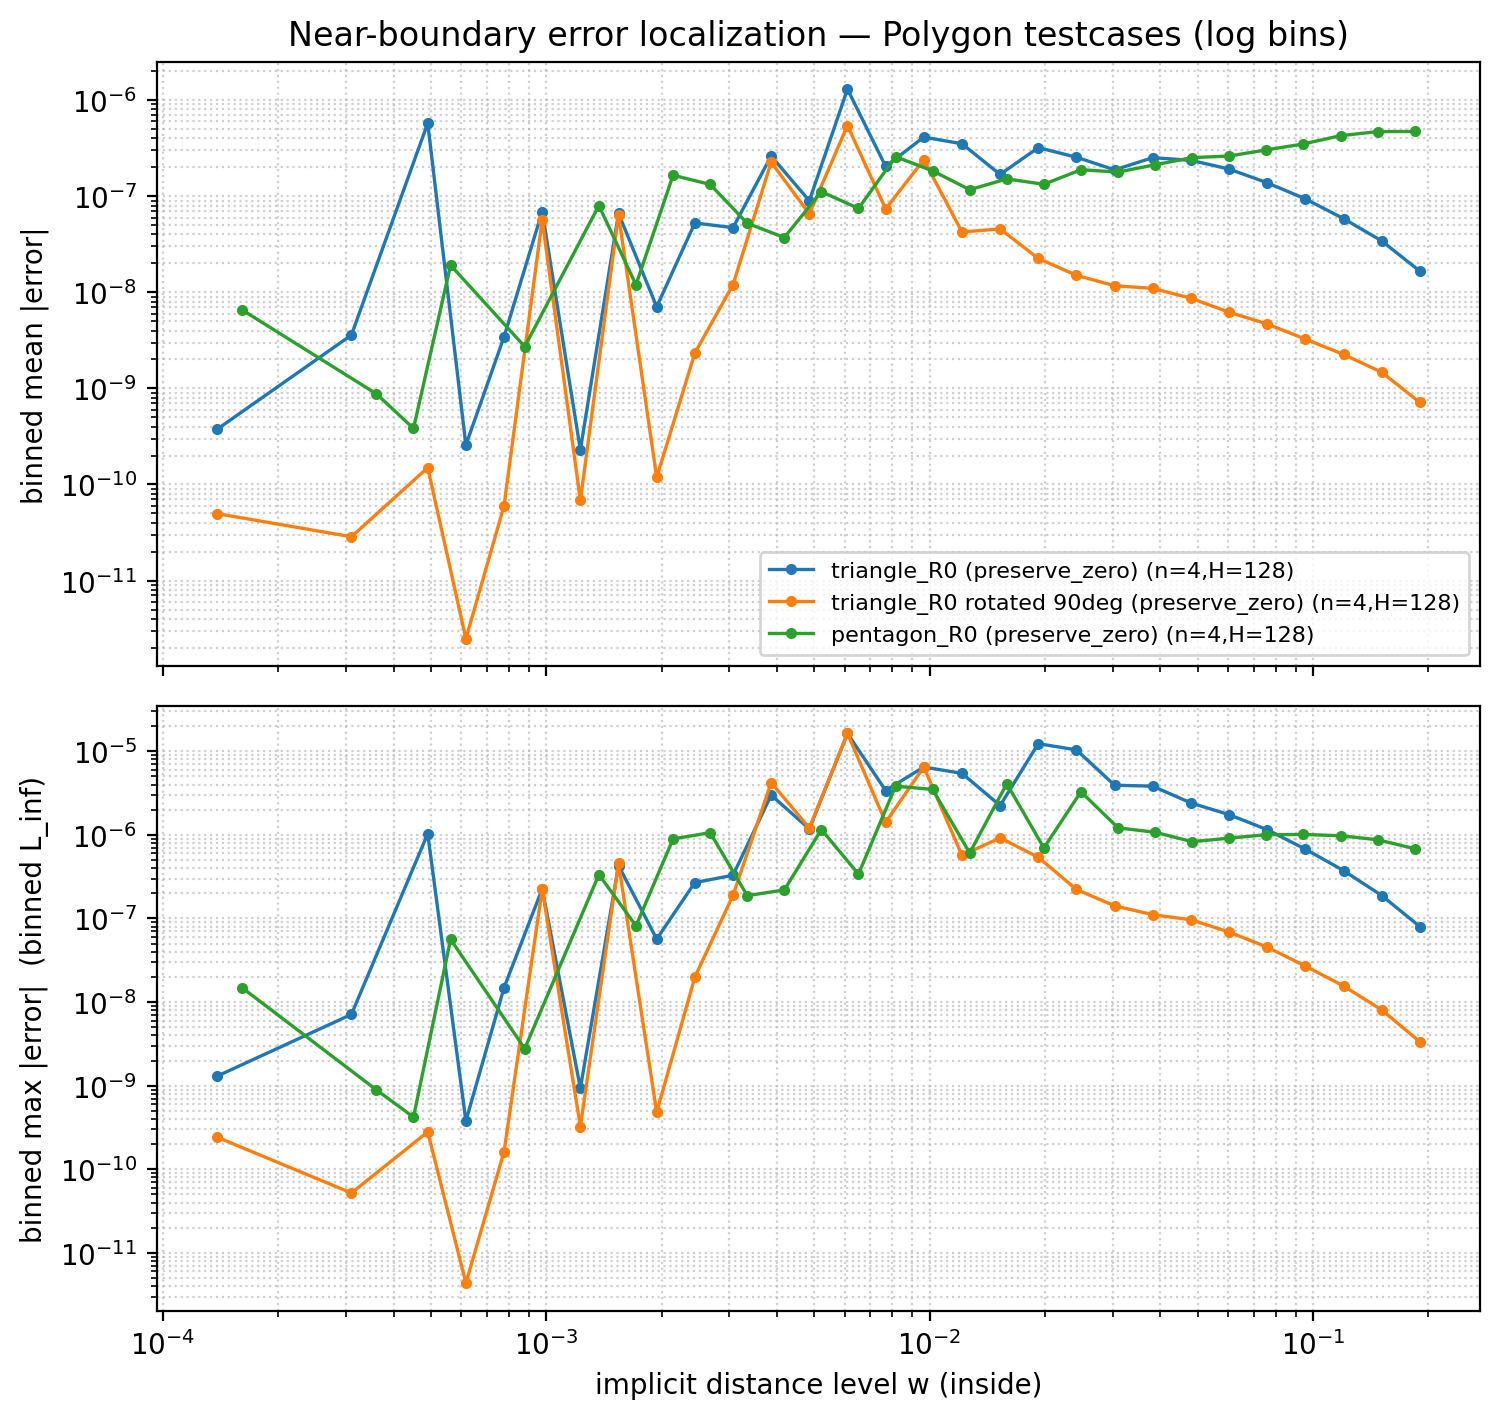

In [12]:
# %%
# Log-binned near-boundary curves (override helpers)
#
# This overrides the earlier `compute_near_boundary_binning` and `plot_near_boundary_curves` so that:
# - bins are spaced logarithmically (with a near-zero bin)
# - plots use a log-scaled x-axis
#
# It also refreshes `res["bins"]` / `res["bins_corr"]` in `all_results` if present,
# and re-plots the Cell 1 near-boundary baseline curves using log bins (mean and binned L_inf).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional, List

def _log_edges_with_zero(x: np.ndarray, n_bins: int, x_max: Optional[float] = None) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64).ravel()
    x = x[np.isfinite(x) & (x >= 0)]
    if x.size == 0:
        return np.array([0.0, 1.0], dtype=np.float64)
    if x_max is None:
        x_max = float(np.quantile(x, 0.995))
    x_max = max(float(x_max), 1e-12)
    pos = x[x > 0]
    if pos.size == 0:
        return np.linspace(0.0, x_max, int(n_bins) + 1)
    x_min = float(np.min(pos))
    if pos.size > 25:
        x_min = float(np.quantile(pos, 0.001))
    x_min = max(x_min, x_max * 1e-8, 1e-15)
    edges_pos = np.geomspace(x_min, x_max, int(n_bins))
    return np.concatenate([[0.0], edges_pos])

def compute_near_boundary_binning(
    w_inside: np.ndarray,
    err_inside: np.ndarray,
    n_bins: int = 30,
    w_max: Optional[float] = None,
    bin_scale: str = "log",
    samples_per_bin: Optional[int] = None,
    seed: int = 0,
 ) -> pd.DataFrame:
    """Bin near-boundary samples by implicit level w and compute mean error per bin.

    bin_scale:
      - 'linear': uniform edges on [0, w_max]
      - 'log': log-spaced edges on (0, w_max] plus an initial [0, w_min] bin

    samples_per_bin: if set, subsample within each bin before computing the mean
    (note: counts always report the full-bin population).
    """
    w_inside = np.asarray(w_inside, dtype=np.float64).ravel()
    err_inside = np.asarray(err_inside, dtype=np.float64).ravel()

    mask = np.isfinite(w_inside) & np.isfinite(err_inside) & (w_inside >= 0)
    w_inside = w_inside[mask]
    err_inside = err_inside[mask]

    if w_inside.size == 0:
        return pd.DataFrame({"w_mid": [], "err_mean": [], "count": []})

    scale = str(bin_scale).strip().lower()
    if scale == "log":
        edges = _log_edges_with_zero(w_inside, int(n_bins), x_max=w_max)
    else:
        if w_max is None:
            w_max = float(np.quantile(w_inside, 0.995))
        w_max = max(float(w_max), 1e-12)
        edges = np.linspace(0.0, w_max, int(n_bins) + 1)

    rng = np.random.default_rng(int(seed))
    rows = []
    for i in range(int(n_bins)):
        a, b = float(edges[i]), float(edges[i + 1])
        sel = (w_inside >= a) & (w_inside < b)
        if not np.any(sel):
            continue
        idx_full = np.flatnonzero(sel)
        idx_mean = idx_full
        if samples_per_bin is not None and idx_full.size > int(samples_per_bin):
            idx_mean = rng.choice(idx_full, size=int(samples_per_bin), replace=False)
        if scale == "log" and a > 0 and b > 0:
            w_mid = float(np.sqrt(a * b))
        else:
            w_mid = 0.5 * (a + b)
        w_mid = max(w_mid, 1e-300)
        rows.append(
            {
                "w_mid": w_mid,
                "err_mean": float(np.mean(err_inside[idx_mean])),
                "count": int(idx_full.size),
            }
        )
    return pd.DataFrame(rows)

def compute_near_boundary_binning_with_max(
    w_inside: np.ndarray,
    err_inside: np.ndarray,
    n_bins: int = 30,
    w_max: Optional[float] = None,
    bin_scale: str = "log",
    samples_per_bin: Optional[int] = None,
    seed: int = 0,
    max_from_full_bin: bool = True,
 ) -> pd.DataFrame:
    """Like `compute_near_boundary_binning`, but also returns per-bin max |error| (binned L_inf)."""
    w_inside = np.asarray(w_inside, dtype=np.float64).ravel()
    err_inside = np.asarray(err_inside, dtype=np.float64).ravel()

    mask = np.isfinite(w_inside) & np.isfinite(err_inside) & (w_inside >= 0)
    w_inside = w_inside[mask]
    err_inside = err_inside[mask]

    if w_inside.size == 0:
        return pd.DataFrame({"w_mid": [], "err_mean": [], "err_max": [], "count": []})

    scale = str(bin_scale).strip().lower()
    if scale == "log":
        edges = _log_edges_with_zero(w_inside, int(n_bins), x_max=w_max)
    else:
        if w_max is None:
            w_max = float(np.quantile(w_inside, 0.995))
        w_max = max(float(w_max), 1e-12)
        edges = np.linspace(0.0, w_max, int(n_bins) + 1)

    rng = np.random.default_rng(int(seed))
    rows = []
    for i in range(int(n_bins)):
        a, b = float(edges[i]), float(edges[i + 1])
        sel = (w_inside >= a) & (w_inside < b)
        if not np.any(sel):
            continue
        idx_full = np.flatnonzero(sel)
        idx_mean = idx_full
        if samples_per_bin is not None and idx_full.size > int(samples_per_bin):
            idx_mean = rng.choice(idx_full, size=int(samples_per_bin), replace=False)
        if scale == "log" and a > 0 and b > 0:
            w_mid = float(np.sqrt(a * b))
        else:
            w_mid = 0.5 * (a + b)
        w_mid = max(w_mid, 1e-300)
        err_mean = float(np.mean(err_inside[idx_mean]))
        if max_from_full_bin:
            err_max = float(np.max(err_inside[idx_full]))
        else:
            err_max = float(np.max(err_inside[idx_mean]))
        rows.append(
            {
                "w_mid": w_mid,
                "err_mean": err_mean,
                "err_max": err_max,
                "count": int(idx_full.size),
            }
        )
    return pd.DataFrame(rows)

def plot_near_boundary_curves(bin_dfs: List[pd.DataFrame], labels: List[str], title: str):
    fig, ax = plt.subplots(figsize=(6.2, 4.0))
    for df, lab in zip(bin_dfs, labels):
        if df is None or df.empty:
            continue
        ax.plot(df["w_mid"], df["err_mean"], marker="o", ms=3, lw=1.2, label=lab)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("implicit distance level w (inside)")
    ax.set_ylabel("binned mean |error|")
    ax.grid(True, which="both", ls=":", alpha=0.6)
    ax.set_title(title)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

# Refresh stored bins if results are already present (keeps downstream plots consistent).
try:
    for _k, _res in list(all_results.items()):
        if not isinstance(_res, dict):
            continue
        if "inside" not in _res or "wP" not in _res:
            continue
        _inside = _res["inside"]
        if "err" in _res:
            _res["bins"] = compute_near_boundary_binning(
                w_inside=_res["wP"][_inside],
                err_inside=_res["err"][_inside],
                n_bins=30,
                bin_scale="log",
            )
        if "err_corr" in _res:
            _res["bins_corr"] = compute_near_boundary_binning(
                w_inside=_res["wP"][_inside],
                err_inside=_res["err_corr"][_inside],
                n_bins=30,
                bin_scale="log",
            )
except Exception:
    pass

# Re-plot the Cell 1 baseline near-boundary curves using refreshed log-binned bins.
# Includes binned mean and binned max (binned L_inf) vs w.
try:
    n_show = DEGREES[-1]
    H_show = HS[-1]
    names = [
        "triangle_R0 (preserve_zero)",
        "triangle_R0 rotated 90deg (preserve_zero)",
        "pentagon_R0 (preserve_zero)",
    ]

    mean_dfs = []
    max_dfs = []
    labels = []
    for name in names:
        res = all_results[(name, n_show, H_show)]
        inside = res["inside"]
        w_inside = res["wP"][inside]
        err_inside = res["err"][inside]
        mean_dfs.append(res["bins"])
        max_dfs.append(
            compute_near_boundary_binning_with_max(
                w_inside=w_inside,
                err_inside=err_inside,
                n_bins=30,
                bin_scale="log",
                samples_per_bin=None,
                seed=0,
                max_from_full_bin=True,
            )
        )
        labels.append(f"{name} (n={n_show},H={H_show})")

    fig, axes = plt.subplots(2, 1, figsize=(7.6, 7.2), sharex=True)
    axm, axM = axes[0], axes[1]
    for df, lab in zip(mean_dfs, labels):
        if df is None or df.empty:
            continue
        axm.plot(df["w_mid"], df["err_mean"], marker="o", ms=3, lw=1.2, label=lab)
    for df, lab in zip(max_dfs, labels):
        if df is None or df.empty:
            continue
        axM.plot(df["w_mid"], df["err_max"], marker="o", ms=3, lw=1.2, label=lab)

    for ax in (axm, axM):
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(True, which="both", ls=":", alpha=0.6)

    axm.set_ylabel("binned mean |error|")
    axM.set_ylabel("binned max |error|  (binned L_inf)")
    axM.set_xlabel("implicit distance level w (inside)")
    axm.set_title("Near-boundary error localization — Polygon testcases (log bins)")
    axm.legend(fontsize=8)
    fig.tight_layout()
    plt.show()
except Exception:
    # Safe to ignore if baseline hasn't been run yet.
    pass

Neural correction sweep on n=4, H=128 (u_exact=expw)

triangle_R0 (preserve_zero)
  best attempt: seed=0, stage=1
  selected: <baseline>
  MAE   1.118e-07 -> 1.118e-07  (x1.000)
  L_inf 1.634e-05 -> 1.634e-05  (x1.000)
  Trials (best first):


,seed,stage,net,hidden,layers,iters,lr,alpha,beta,l2,w0_first,w0_hidden,passed_guard,guard_limit,mae_ratio,linf_ratio,mae,linf
5,0,1,ReLU,96,2,900,0.00001,360.0,360.0,0.000030,30.0,30.0,True,1.173895e-07,1.013646,1.003171,1.133252e-07,0.000016
4,0,1,ReLU,64,2,700,0.00002,320.0,320.0,0.000100,30.0,30.0,True,1.173895e-07,1.024449,1.007210,1.145329e-07,0.000016
3,0,1,ReLU,128,3,650,0.00003,300.0,300.0,0.000003,30.0,30.0,True,1.173895e-07,1.046153,1.010856,1.169594e-07,0.000017
2,0,1,ReLU,128,3,450,0.00005,240.0,240.0,0.000001,30.0,30.0,False,1.173895e-07,1.110726,1.021497,1.241786e-07,0.000017
0,0,1,ReLU,64,2,300,0.00008,160.0,160.0,0.000003,30.0,30.0,False,1.173895e-07,1.518278,1.064262,1.697428e-07,0.000017
1,0,1,ReLU,96,2,380,0.00006,200.0,200.0,0.000001,30.0,30.0,False,1.173895e-07,1.375042,1.065569,1.537291e-07,0.000017



triangle_R0 rotated 90deg (preserve_zero)
  best attempt: seed=0, stage=1
  selected: <baseline>
  MAE   1.240e-08 -> 1.240e-08  (x1.000)
  L_inf 1.634e-05 -> 1.634e-05  (x1.000)
  Trials (best first):


,seed,stage,net,hidden,layers,iters,lr,alpha,beta,l2,w0_first,w0_hidden,passed_guard,guard_limit,mae_ratio,linf_ratio,mae,linf
5,0,1,ReLU,96,2,900,0.00001,360.0,360.0,0.000030,30.0,30.0,False,1.302445e-08,1.164329,1.003171,1.444261e-08,0.000016
4,0,1,ReLU,64,2,700,0.00002,320.0,320.0,0.000100,30.0,30.0,False,1.302445e-08,1.284198,1.007210,1.592950e-08,0.000016
3,0,1,ReLU,128,3,650,0.00003,300.0,300.0,0.000003,30.0,30.0,False,1.302445e-08,1.531953,1.010856,1.900271e-08,0.000017
2,0,1,ReLU,128,3,450,0.00005,240.0,240.0,0.000001,30.0,30.0,False,1.302445e-08,2.256410,1.021497,2.798904e-08,0.000017
0,0,1,ReLU,64,2,300,0.00008,160.0,160.0,0.000003,30.0,30.0,False,1.302445e-08,6.636382,1.064263,8.231926e-08,0.000017
1,0,1,ReLU,96,2,380,0.00006,200.0,200.0,0.000001,30.0,30.0,False,1.302445e-08,5.070944,1.065569,6.290119e-08,0.000017



pentagon_R0 (preserve_zero)
  best attempt: seed=0, stage=1
  selected: ReLU(h=128,L=3,it=450,bs=256,lr=5e-05,a=240,b=240,l2=1e-06)
  MAE   3.762e-07 -> 3.861e-07  (x1.026)
  L_inf 4.098e-06 -> 4.029e-06  (x0.983)
  Trials (best first):


,seed,stage,net,hidden,layers,iters,lr,alpha,beta,l2,w0_first,w0_hidden,passed_guard,guard_limit,mae_ratio,linf_ratio,mae,linf
2,0,1,ReLU,128,3,450,0.00005,240.0,240.0,0.000001,30.0,30.0,True,3.950608e-07,1.026303,0.983179,3.861449e-07,0.000004
3,0,1,ReLU,128,3,650,0.00003,300.0,300.0,0.000003,30.0,30.0,True,3.950608e-07,1.010846,0.995902,3.803290e-07,0.000004
4,0,1,ReLU,64,2,700,0.00002,320.0,320.0,0.000100,30.0,30.0,True,3.950608e-07,1.005715,0.998383,3.783986e-07,0.000004
5,0,1,ReLU,96,2,900,0.00001,360.0,360.0,0.000030,30.0,30.0,True,3.950608e-07,1.004581,0.999232,3.779719e-07,0.000004
0,0,1,ReLU,64,2,300,0.00008,160.0,160.0,0.000003,30.0,30.0,False,3.950608e-07,1.138970,0.859867,4.285355e-07,0.000004
1,0,1,ReLU,96,2,380,0.00006,200.0,200.0,0.000001,30.0,30.0,False,3.950608e-07,1.098508,0.902546,4.133119e-07,0.000004


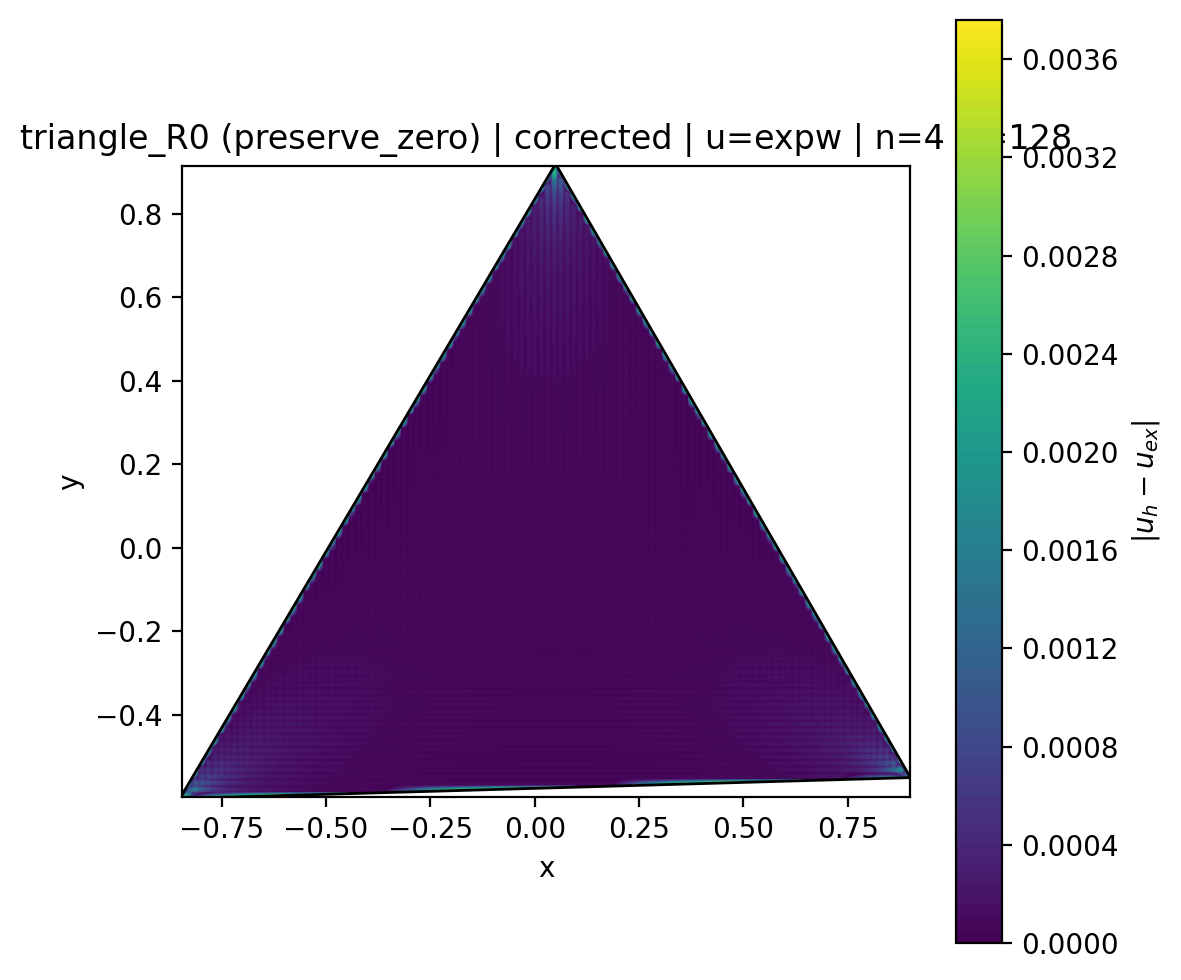

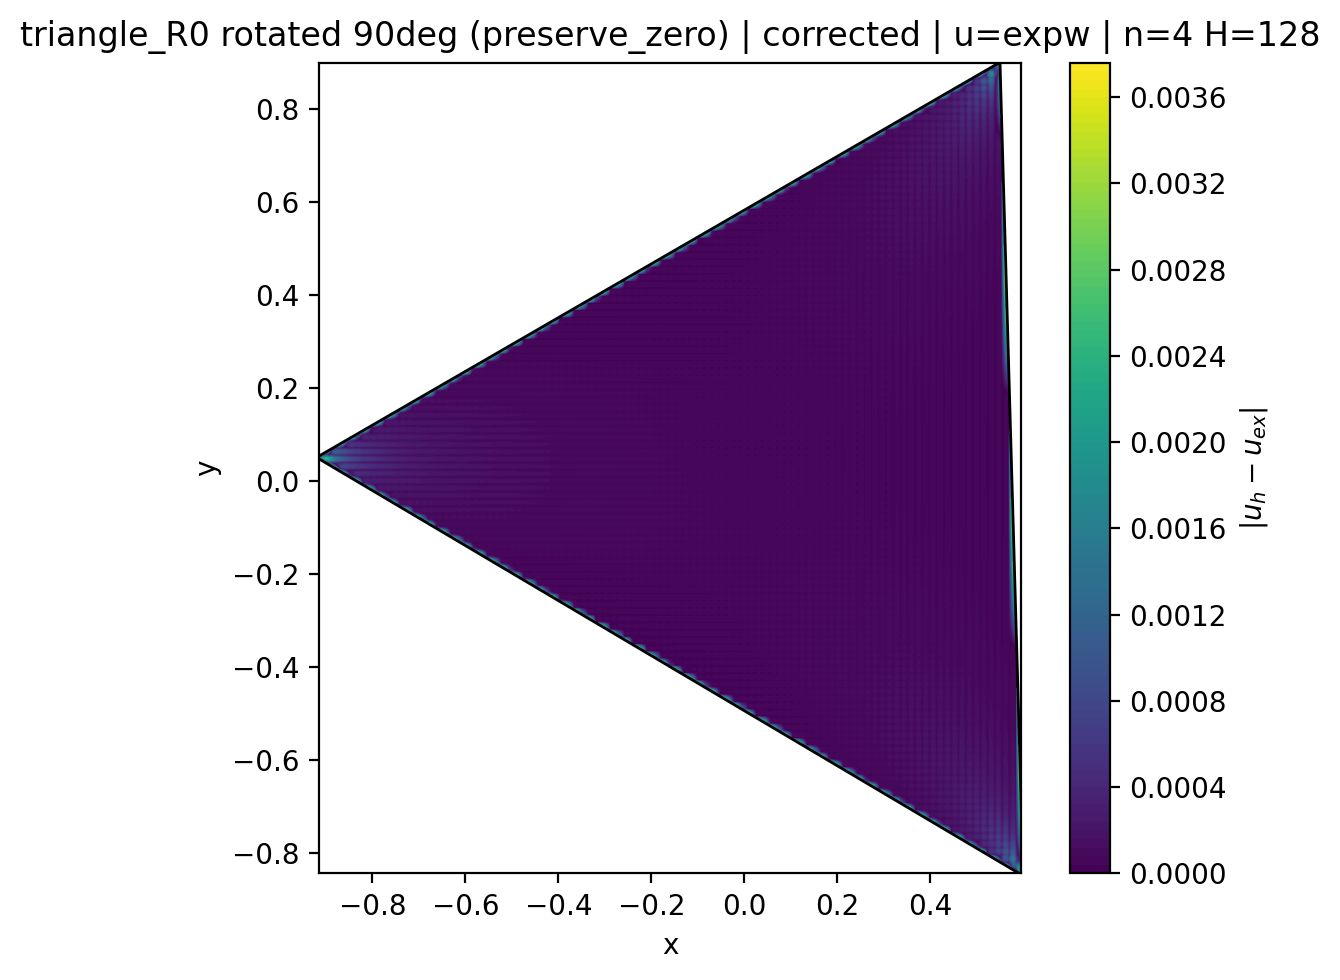

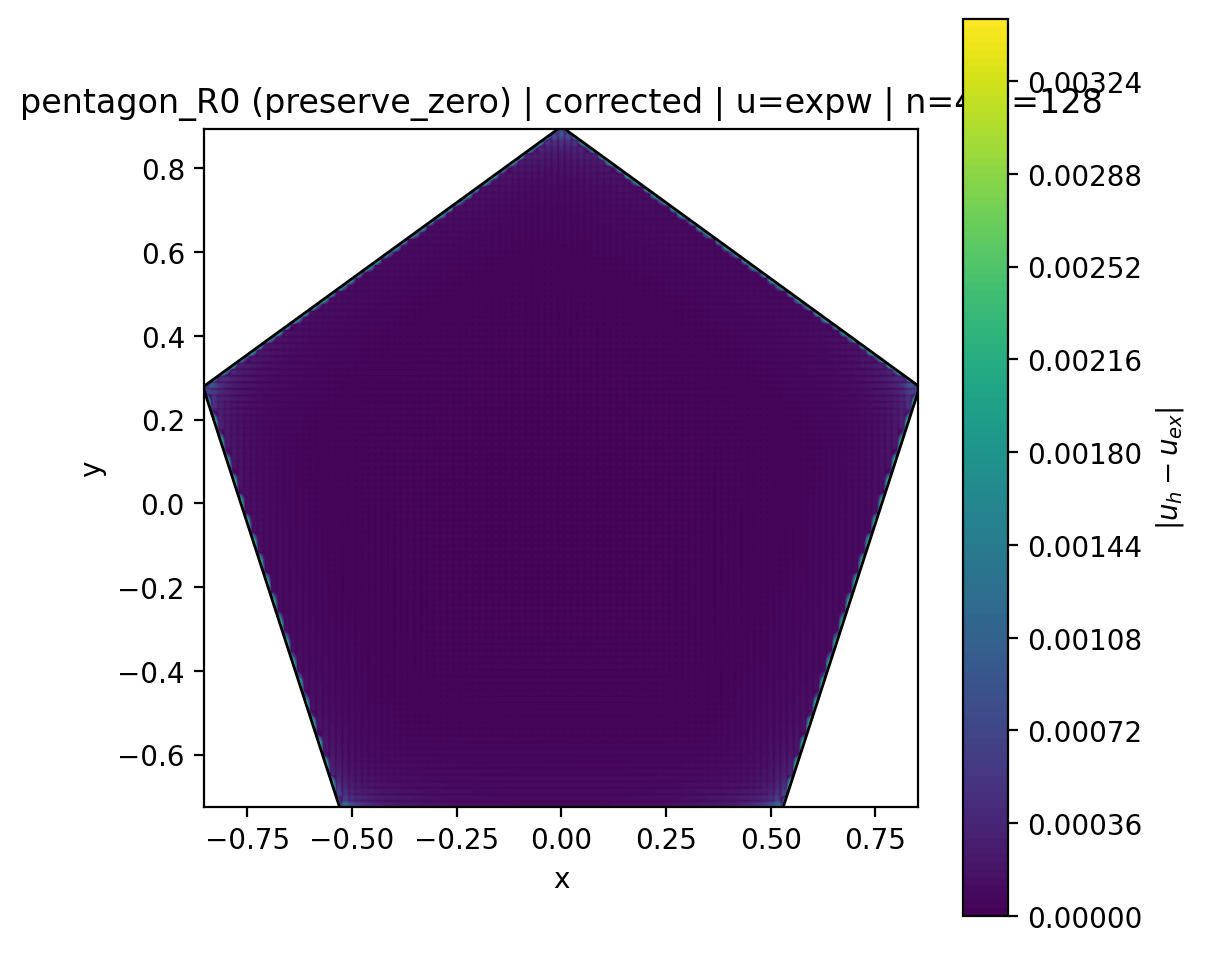

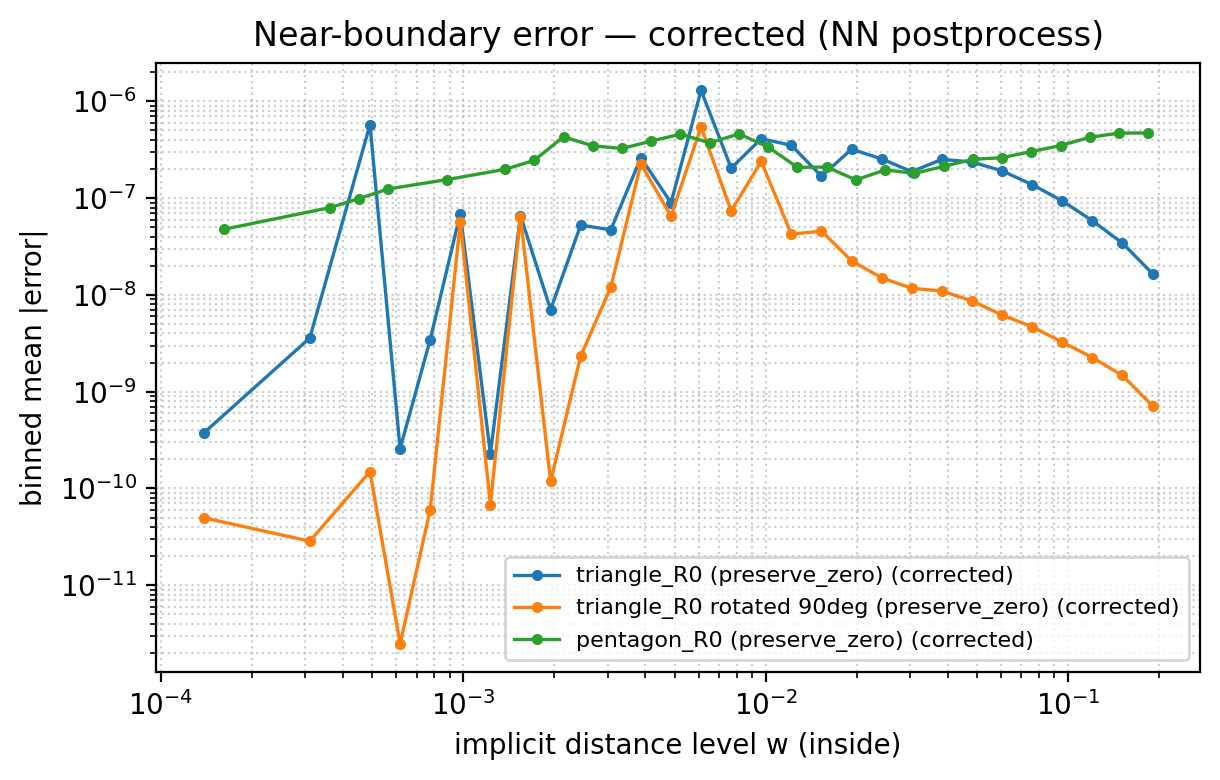

In [8]:
# %%
# Neural residual correction (post-process collocation solution)
#
# Goal: try multiple NN hyperparameters and keep searching for a guarded improvement.
# NOTE: All heavy lifting lives in `Neural Analysis/colloc_nn_correction.py`.

import importlib
import colloc_nn_correction as cnc

# Always reload during iteration (ensures edits to colloc_nn_correction.py take effect).
importlib.reload(cnc)

cnc.set_seed(0)

# Use the same resolution that was used for plotting/summary.
try:
    n_show
    H_show
except NameError:
    n_show = DEGREES[-1]
    H_show = HS[-1]

# Guardrail: avoid trading away too much MAE for L_inf.
GUARD_MAE_FRAC = 0.05  # +5% relative MAE allowed
GUARD_MAE_ABS = 5e-10  # absolute slack for ultra-small MAE baselines

# Feature scaling for polygon distances.
DIST_SCALE = 2.0

# Map geom name -> model, so we can rebuild f and u_exact.
MODEL_BY_NAME = {gv.name: gv.model for gv in GEOMS}

# Only run correction for the polygon testcases.
TARGET_NAMES = [
    "triangle_R0 (preserve_zero)",
    "triangle_R0 rotated 90deg (preserve_zero)",
    "pentagon_R0 (preserve_zero)",
]


def _cfg_str(cfg: cnc.SweepConfig) -> str:
    if cfg is None:
        return "<baseline>"
    t = cfg.net_type
    if str(t).strip().lower() == "siren":
        return (
            f"{t}(h={cfg.hidden},L={cfg.layers},it={cfg.iters},bs={cfg.batch_size},"
            f"lr={cfg.lr:g},a={cfg.boundary_alpha:g},b={cfg.sample_beta:g},l2={cfg.corr_l2:g},"
            f"w0={cfg.first_omega_0:g}/{cfg.hidden_omega_0:g})"
        )
    return (
        f"{t}(h={cfg.hidden},L={cfg.layers},it={cfg.iters},bs={cfg.batch_size},"
        f"lr={cfg.lr:g},a={cfg.boundary_alpha:g},b={cfg.sample_beta:g},l2={cfg.corr_l2:g})"
    )


# Candidate pool (staged). Collocation baseline is already extremely accurate,
# so we bias towards conservative, localized corrections.
CFG_POOL = [
    # ReLU: small to medium
    cnc.SweepConfig(net_type="ReLU", lr=8e-5, hidden=64, layers=2, iters=300, batch_size=256, boundary_alpha=160.0, sample_beta=160.0, corr_l2=3e-6),
    cnc.SweepConfig(net_type="ReLU", lr=6e-5, hidden=96, layers=2, iters=380, batch_size=256, boundary_alpha=200.0, sample_beta=200.0, corr_l2=1e-6),
    cnc.SweepConfig(net_type="ReLU", lr=5e-5, hidden=128, layers=3, iters=450, batch_size=256, boundary_alpha=240.0, sample_beta=240.0, corr_l2=1e-6),
    cnc.SweepConfig(net_type="ReLU", lr=3e-5, hidden=128, layers=3, iters=650, batch_size=384, boundary_alpha=300.0, sample_beta=300.0, corr_l2=3e-6),

    # ReLU: very conservative (heavy regularization)
    cnc.SweepConfig(net_type="ReLU", lr=2e-5, hidden=64, layers=2, iters=700, batch_size=384, boundary_alpha=320.0, sample_beta=320.0, corr_l2=1e-4),
    cnc.SweepConfig(net_type="ReLU", lr=1e-5, hidden=96, layers=2, iters=900, batch_size=512, boundary_alpha=360.0, sample_beta=360.0, corr_l2=3e-5),

    # SIREN: lower omegas (smoother)
    cnc.SweepConfig(net_type="SIREN", lr=2e-5, hidden=64, layers=2, iters=500, batch_size=256, boundary_alpha=240.0, sample_beta=240.0, corr_l2=3e-6, first_omega_0=15.0, hidden_omega_0=15.0),
    cnc.SweepConfig(net_type="SIREN", lr=2e-5, hidden=64, layers=2, iters=650, batch_size=256, boundary_alpha=280.0, sample_beta=280.0, corr_l2=3e-6, first_omega_0=20.0, hidden_omega_0=20.0),

    # SIREN: moderate/high omegas (boundary layers)
    cnc.SweepConfig(net_type="SIREN", lr=2e-5, hidden=64, layers=2, iters=650, batch_size=256, boundary_alpha=300.0, sample_beta=300.0, corr_l2=1e-6, first_omega_0=45.0, hidden_omega_0=45.0),
    cnc.SweepConfig(net_type="SIREN", lr=1e-5, hidden=96, layers=2, iters=900, batch_size=384, boundary_alpha=360.0, sample_beta=360.0, corr_l2=3e-6, first_omega_0=60.0, hidden_omega_0=60.0),
]

# Stages: try smaller subset first, then full pool.
STAGE_SIZES = [6, 10] if not SMOKE else [4, 6]

# Try a couple of different seeds (helps because the residual training is stochastic).
SEEDS = [0, 1] if not SMOKE else [0]

print(f"Neural correction sweep on n={n_show}, H={H_show} (u_exact={U_EXACT_TYPE})")

for name in TARGET_NAMES:
    key = (name, n_show, H_show)
    if key not in all_results:
        print(f"[skip] missing result for {key}")
        continue

    res = all_results[key]
    model = MODEL_BY_NAME[name]

    if not hasattr(model, "_vertices_np"):
        print(f"[skip] {name}: model has no _vertices_np")
        continue

    vertices = model._vertices_np

    # Manufactured problem in physical coordinates.
    f_phys, u_exact_phys, _wfct_phys = make_manufactured_problem(model, u_type=U_EXACT_TYPE)

    u_base = res["Uxy"]
    xP = res["xP"]
    yP = res["yP"]
    inside = res["inside"]

    # Baseline metrics
    u_ex_grid = u_exact_phys(xP, yP)
    mae0 = float(np.mean(np.abs(u_base[inside] - u_ex_grid[inside])))
    linf0 = float(np.max(np.abs(u_base[inside] - u_ex_grid[inside])))

    best_out = None
    best_seed = None
    best_stage = None
    best_trials_df = None

    # Keep trying across seeds/stages.
    for seed in SEEDS:
        for stage_k, stage_n in enumerate(STAGE_SIZES, start=1):
            sweep = CFG_POOL[: int(stage_n)]
            out = cnc.run_guarded_sweep(
                u_base=u_base,
                xP=xP,
                yP=yP,
                inside=inside,
                weight_model=model.double(),
                vertices_ccw_np=vertices,
                f_phys=f_phys,
                u_exact_phys=u_exact_phys,
                dist_scale=DIST_SCALE,
                guard_mae_frac=GUARD_MAE_FRAC,
                guard_mae_abs=GUARD_MAE_ABS,
                select_by="linf_mae",
                sweep=sweep,
                seed=int(seed),
                device="cpu",
            )

            # Build trials table for inspection
            rows = []
            for t in out.get("trials", []):
                cfg = t.get("cfg", None)
                rows.append(
                    {
                        "seed": seed,
                        "stage": stage_k,
                        "net": None if cfg is None else cfg.net_type,
                        "hidden": None if cfg is None else cfg.hidden,
                        "layers": None if cfg is None else cfg.layers,
                        "iters": None if cfg is None else cfg.iters,
                        "lr": None if cfg is None else cfg.lr,
                        "alpha": None if cfg is None else cfg.boundary_alpha,
                        "beta": None if cfg is None else cfg.sample_beta,
                        "l2": None if cfg is None else cfg.corr_l2,
                        "w0_first": None if cfg is None else getattr(cfg, "first_omega_0", None),
                        "w0_hidden": None if cfg is None else getattr(cfg, "hidden_omega_0", None),
                        "passed_guard": bool(t.get("passed_guard", False)),
                        "guard_limit": float(t.get("guard_limit", np.nan)),
                        "mae_ratio": float(t.get("mae_ratio", np.nan)),
                        "linf_ratio": float(t.get("linf_ratio", np.nan)),
                        "mae": float(t.get("mae", np.nan)),
                        "linf": float(t.get("linf", np.nan)),
                    }
                )

            trials_df = pd.DataFrame(rows)
            if not trials_df.empty:
                trials_df = trials_df.sort_values(
                    ["passed_guard", "linf_ratio", "mae_ratio"], ascending=[False, True, True]
                )

            # Keep the best attempt across seeds/stages by (linf, mae)
            # (since run_guarded_sweep itself never returns worse than baseline).
            if best_out is None:
                best_out, best_seed, best_stage, best_trials_df = out, seed, stage_k, trials_df
            else:
                # Compare resulting corrected metrics
                u_corr_a = best_out["u_corrected"]
                u_corr_b = out["u_corrected"]
                mae_a = float(np.mean(np.abs(u_corr_a[inside] - u_ex_grid[inside])))
                linf_a = float(np.max(np.abs(u_corr_a[inside] - u_ex_grid[inside])))
                mae_b = float(np.mean(np.abs(u_corr_b[inside] - u_ex_grid[inside])))
                linf_b = float(np.max(np.abs(u_corr_b[inside] - u_ex_grid[inside])))
                if (linf_b, mae_b) < (linf_a, mae_a):
                    best_out, best_seed, best_stage, best_trials_df = out, seed, stage_k, trials_df

            # Early exit if we got a real improvement in L_inf.
            # (MAE is already guarded.)
            if not out.get("used_baseline", False):
                u_corr = out["u_corrected"]
                linf1 = float(np.max(np.abs(u_corr[inside] - u_ex_grid[inside])))
                if linf1 < linf0:
                    break
        # exit seed loop if improved
        if best_out is not None and (not best_out.get("used_baseline", False)):
            u_corr = best_out["u_corrected"]
            linf1 = float(np.max(np.abs(u_corr[inside] - u_ex_grid[inside])))
            if linf1 < linf0:
                break

    out = best_out

    u_corr = out["u_corrected"]
    mae1 = float(np.mean(np.abs(u_corr[inside] - u_ex_grid[inside])))
    linf1 = float(np.max(np.abs(u_corr[inside] - u_ex_grid[inside])))

    # Store corrected fields for downstream plotting.
    res["Uxy_corr"] = u_corr
    res["corr_nn"] = out["corr"]
    res["err_corr"] = np.abs(u_corr - u_ex_grid)
    res["bins_corr"] = compute_near_boundary_binning(
        w_inside=res["wP"][inside], err_inside=res["err_corr"][inside], n_bins=30
    )

    print(f"\n{name}")
    print(f"  best attempt: seed={best_seed}, stage={best_stage}")
    print(f"  selected: {_cfg_str(out.get('selected_cfg', None))}")
    print(f"  MAE   {mae0:.3e} -> {mae1:.3e}  (x{mae1/max(mae0,1e-300):.3f})")
    print(f"  L_inf {linf0:.3e} -> {linf1:.3e}  (x{linf1/max(linf0,1e-300):.3f})")

    if best_trials_df is not None and not best_trials_df.empty:
        print("  Trials (best first):")
        display(best_trials_df.head(15))

# Optional: plot corrected error fields (reuses existing plot function)
PLOT_CORRECTED = True
if PLOT_CORRECTED:
    for name in TARGET_NAMES:
        key = (name, n_show, H_show)
        if key not in all_results:
            continue
        res = all_results[key]
        if "Uxy_corr" not in res:
            continue
        res_corr = dict(res)
        res_corr["Uxy"] = res["Uxy_corr"]
        plot_error_field(
            res_corr,
            title=f"{name} | corrected | u={U_EXACT_TYPE} | n={n_show} H={H_show}",
        )

    # Corrected near-boundary mean curves
    bin_dfs_c = []
    labels_c = []
    for name in TARGET_NAMES:
        key = (name, n_show, H_show)
        if key not in all_results:
            continue
        res = all_results[key]
        if "bins_corr" not in res:
            continue
        bin_dfs_c.append(res["bins_corr"])
        labels_c.append(f"{name} (corrected)")
    if bin_dfs_c:
        plot_near_boundary_curves(
            bin_dfs_c, labels_c, title="Near-boundary error — corrected (NN postprocess)"
        )


Global error summary (inside Ω) for n=4, H=128 (u_exact=expw)


,geom,mae_base,mae_corr,mae_ratio,linf_base,linf_corr,linf_ratio
0,triangle_R0 (preserve_zero),1.117995e-07,1.117995e-07,1.000000,0.000016,0.000016,1.000000
1,triangle_R0 rotated 90deg (preserve_zero),1.240424e-08,1.240424e-08,1.000000,0.000016,0.000016,1.000000
2,pentagon_R0 (preserve_zero),3.762484e-07,3.861449e-07,1.026303,0.000004,0.000004,0.983179


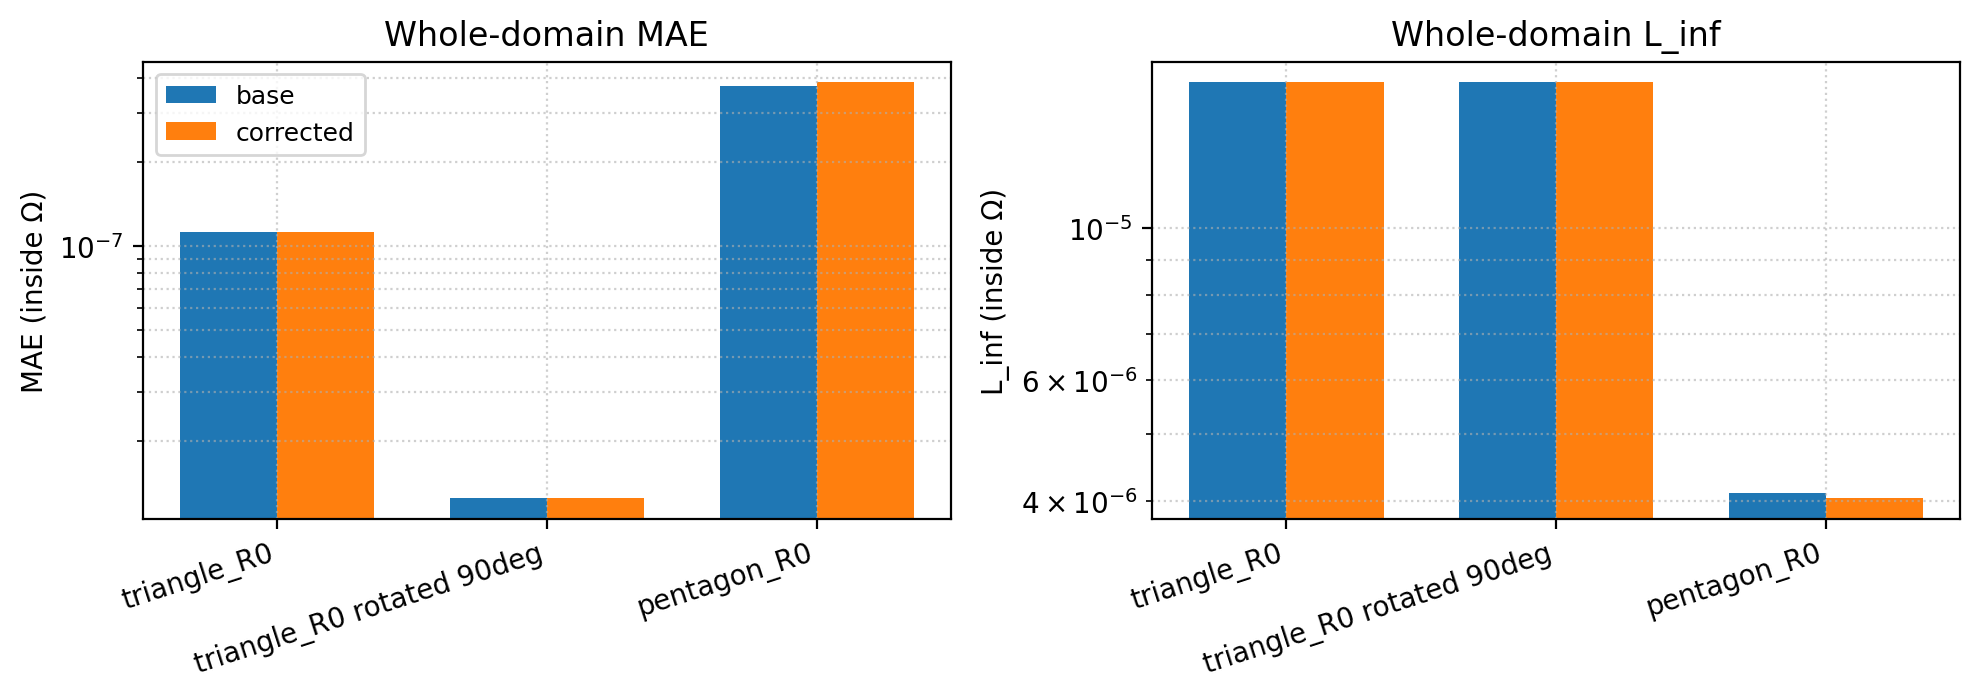

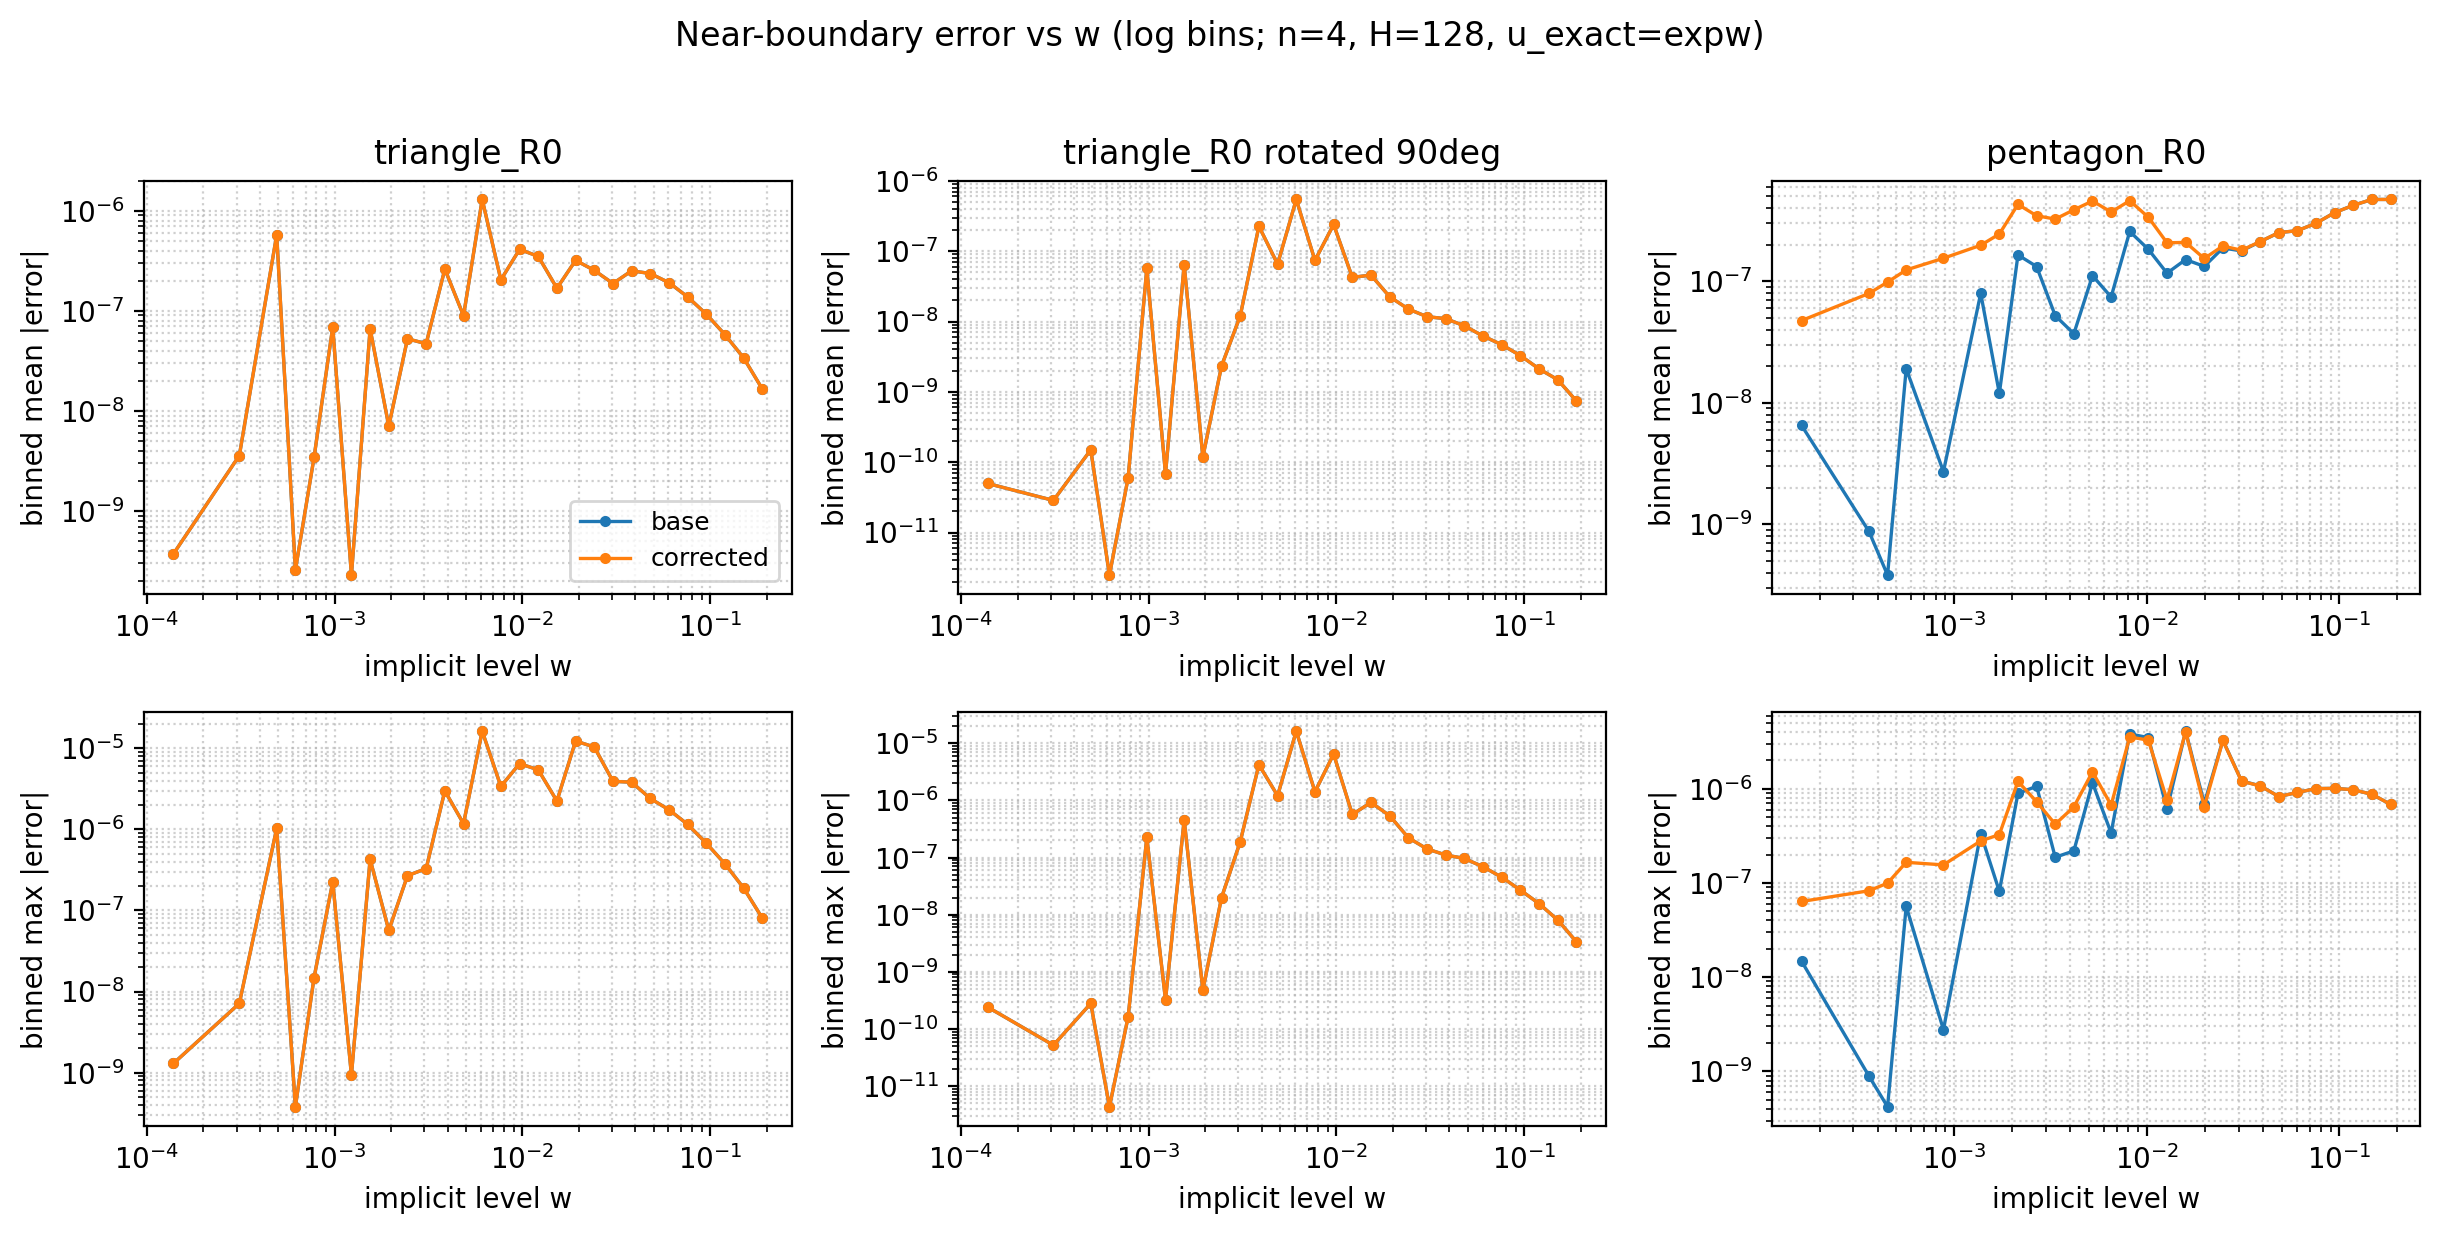

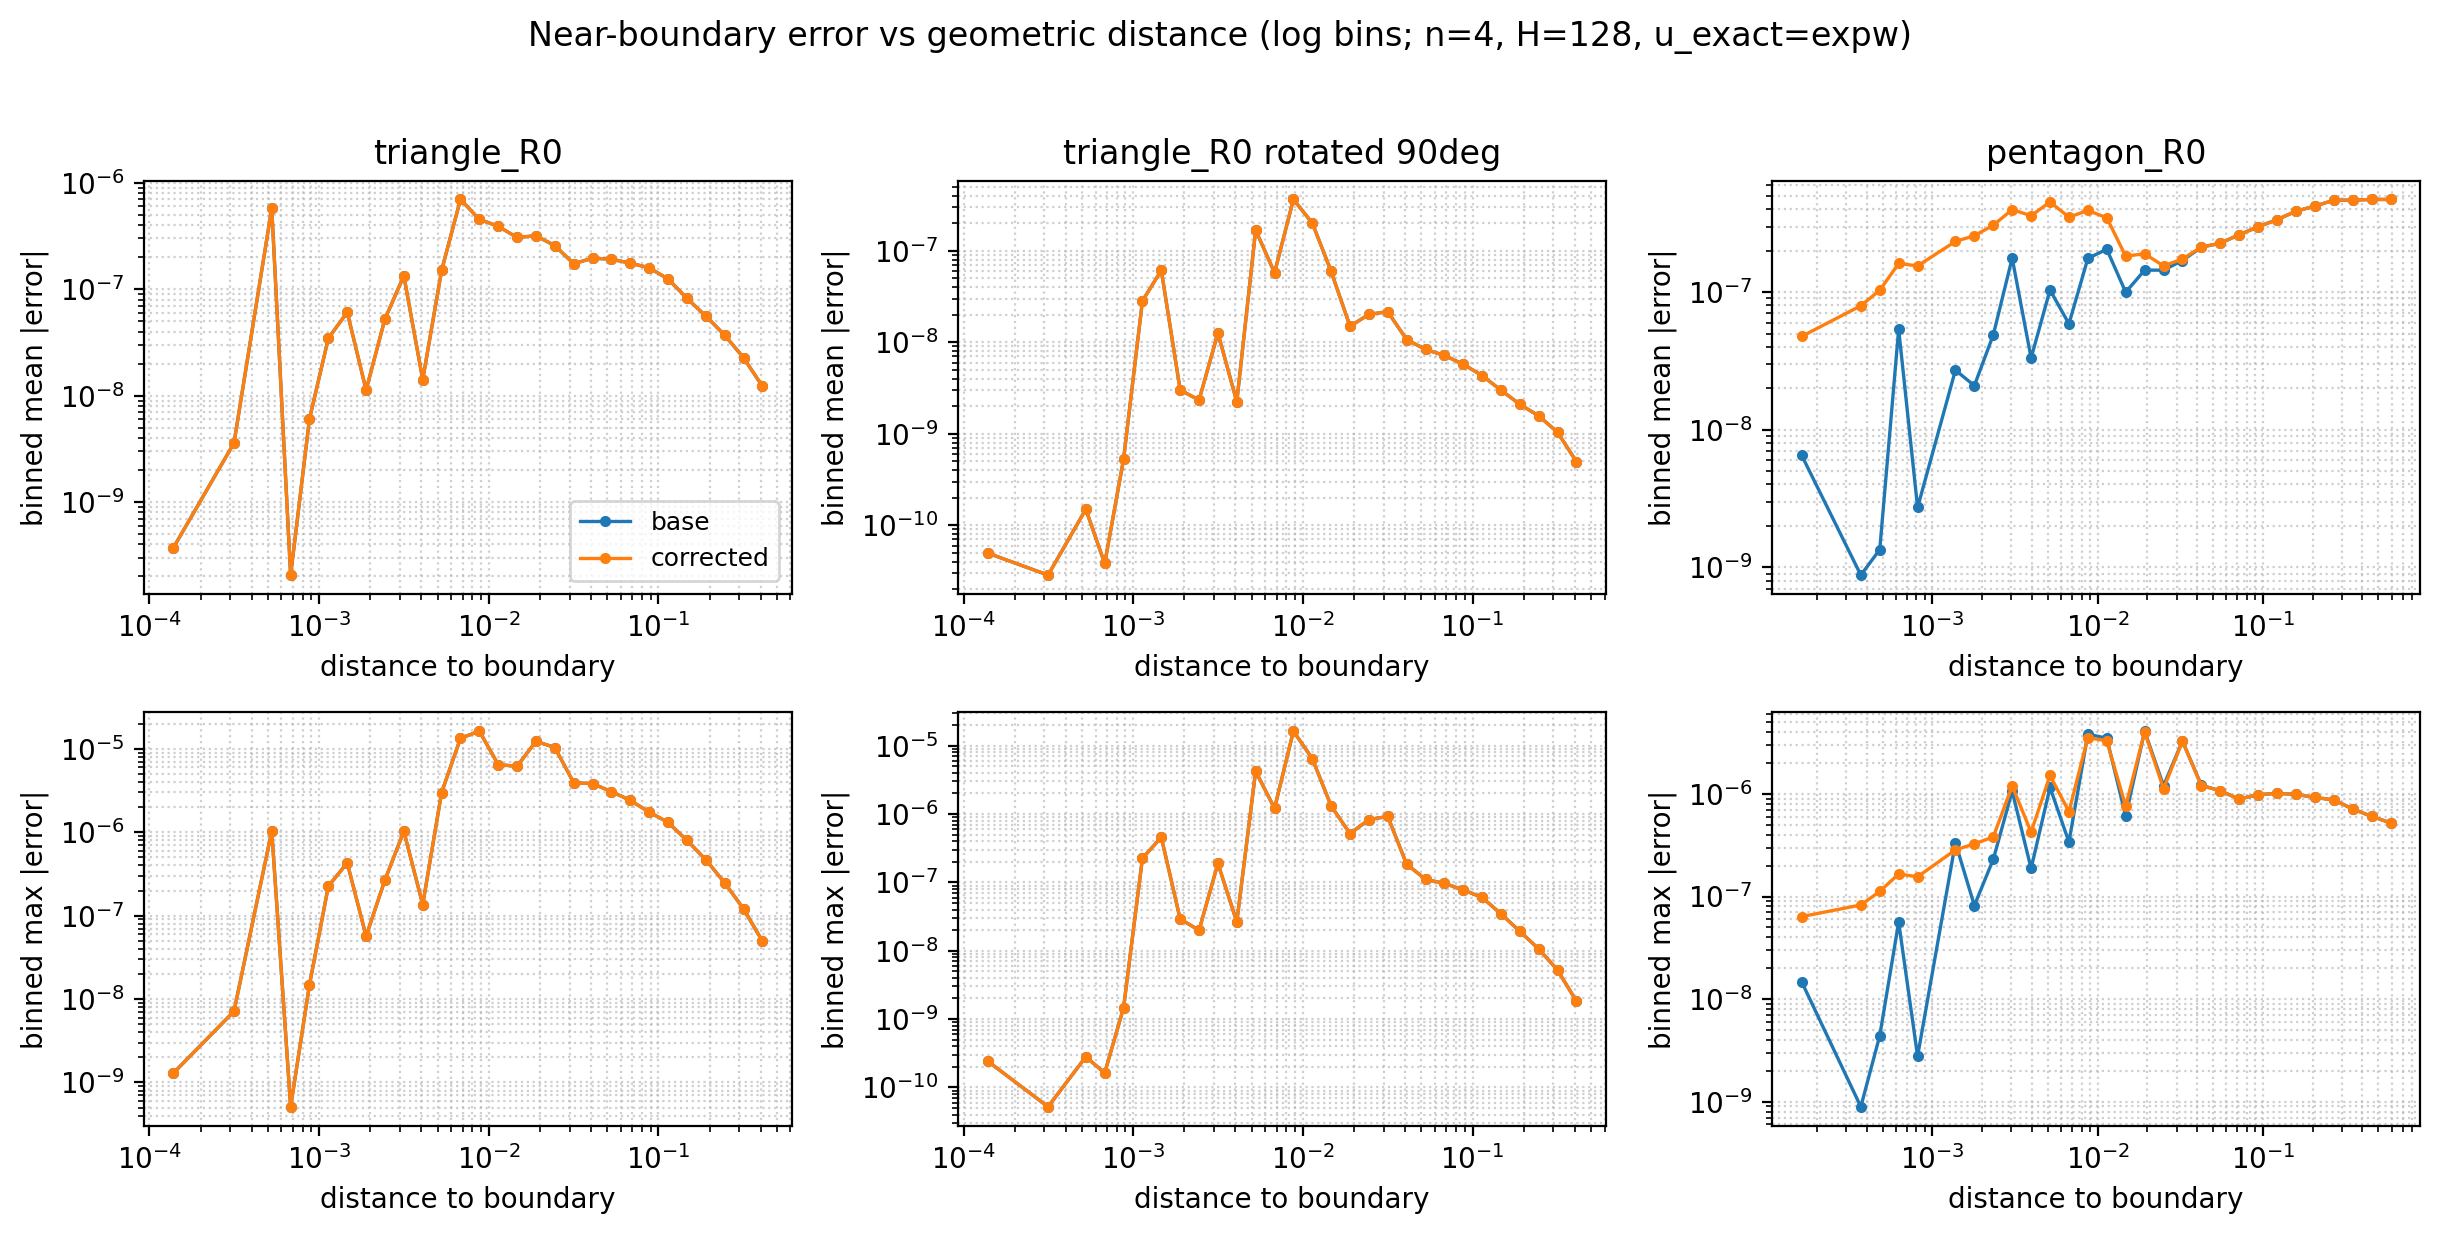

In [9]:
# %%
# Visualize NN correction impact:
# - whole-domain MAE and L_inf (inside Ω)
# - near-boundary behavior vs implicit level w (binned mean and binned max)
# - near-boundary behavior vs *geometric* distance to boundary (polygon only)

# Pick the same targets used for correction.
try:
    names = list(TARGET_NAMES)
except NameError:
    names = [
        "triangle_R0 (preserve_zero)",
        "triangle_R0 rotated 90deg (preserve_zero)",
        "pentagon_R0 (preserve_zero)",
    ]

try:
    n_show
    H_show
except NameError:
    n_show = DEGREES[-1]
    H_show = HS[-1]

# Make sure corrected fields exist.
missing = []
for nm in names:
    key = (nm, n_show, H_show)
    if key not in all_results or ("Uxy_corr" not in all_results[key]):
        missing.append(nm)

if missing:
    print("Missing corrected results for:")
    for nm in missing:
        print(f"  - {nm}")
    raise RuntimeError("Run the NN correction cell first (the one above).")

# Build or reuse model map.
try:
    MODEL_BY_NAME
except NameError:
    MODEL_BY_NAME = {gv.name: gv.model for gv in GEOMS}

def _log_edges_with_zero(x: np.ndarray, n_bins: int, x_max: Optional[float] = None) -> np.ndarray:
    """Return edges with a [0, x_min] bin + log-spaced bins up to x_max."""
    x = np.asarray(x, dtype=np.float64).ravel()
    x = x[np.isfinite(x) & (x >= 0)]
    if x.size == 0:
        return np.array([0.0, 1.0], dtype=np.float64)
    if x_max is None:
        x_max = float(np.quantile(x, 0.995))
    x_max = max(float(x_max), 1e-12)
    pos = x[x > 0]
    if pos.size == 0:
        return np.linspace(0.0, x_max, int(n_bins) + 1)
    x_min = float(np.min(pos))
    if pos.size > 25:
        x_min = float(np.quantile(pos, 0.001))
    x_min = max(x_min, x_max * 1e-8, 1e-15)
    # edges_pos has length n_bins: [x_min ... x_max]; add 0 to get n_bins+1 edges -> n_bins bins
    edges_pos = np.geomspace(x_min, x_max, int(n_bins))
    return np.concatenate([[0.0], edges_pos])

def compute_near_boundary_binning_with_max(
    w_inside: np.ndarray,
    err_inside: np.ndarray,
    n_bins: int = 30,
    w_max: Optional[float] = None,
    bin_scale: str = "log",
    samples_per_bin: Optional[int] = 500,
    seed: int = 0,
    max_from_full_bin: bool = True,
 ) -> pd.DataFrame:
    """Bin near-boundary samples by implicit level w and compute mean+max error per bin.

    bin_scale:
      - 'linear': uniform bins on [0, w_max]
      - 'log': log-spaced bins on (0, w_max] plus a near-zero bin

    samples_per_bin: if set, subsample within each bin for the mean estimate.
    max_from_full_bin: if True, compute max over the full bin (not the subsample).
    """
    w_inside = np.asarray(w_inside, dtype=np.float64).ravel()
    err_inside = np.asarray(err_inside, dtype=np.float64).ravel()

    mask = np.isfinite(w_inside) & np.isfinite(err_inside) & (w_inside >= 0)
    w_inside = w_inside[mask]
    err_inside = err_inside[mask]

    if w_inside.size == 0:
        return pd.DataFrame({"w_mid": [], "err_mean": [], "err_max": [], "count": []})

    scale = str(bin_scale).strip().lower()
    if scale == "log":
        edges = _log_edges_with_zero(w_inside, int(n_bins), x_max=w_max)
    else:
        if w_max is None:
            w_max = float(np.quantile(w_inside, 0.995))
        w_max = max(float(w_max), 1e-12)
        edges = np.linspace(0.0, w_max, int(n_bins) + 1)

    rng = np.random.default_rng(int(seed))
    rows = []
    for i in range(int(n_bins)):
        a, b = float(edges[i]), float(edges[i + 1])
        sel = (w_inside >= a) & (w_inside < b)
        if not np.any(sel):
            continue
        idx_full = np.flatnonzero(sel)
        idx_mean = idx_full
        if samples_per_bin is not None and idx_full.size > int(samples_per_bin):
            idx_mean = rng.choice(idx_full, size=int(samples_per_bin), replace=False)
        if scale == "log" and a > 0 and b > 0:
            w_mid = float(np.sqrt(a * b))
        else:
            w_mid = 0.5 * (a + b)
        w_mid = max(w_mid, 1e-300)
        err_mean = float(np.mean(err_inside[idx_mean]))
        if max_from_full_bin:
            err_max = float(np.max(err_inside[idx_full]))
        else:
            err_max = float(np.max(err_inside[idx_mean]))
        rows.append(
            {
                "w_mid": w_mid,
                "err_mean": err_mean,
                "err_max": err_max,
                "count": int(idx_full.size),
            }
        )

    return pd.DataFrame(rows)

def _polygon_min_edge_distance(x: np.ndarray, y: np.ndarray, vertices_ccw: np.ndarray) -> np.ndarray:
    """Compute min distance from points to polygon edges (Euclidean, to segments)."""
    x = np.asarray(x, dtype=np.float64).ravel()
    y = np.asarray(y, dtype=np.float64).ravel()
    v = np.asarray(vertices_ccw, dtype=np.float64)
    m = int(v.shape[0])
    dmin = np.full_like(x, np.inf, dtype=np.float64)

    for i in range(m):
        x1, y1 = v[i, 0], v[i, 1]
        x2, y2 = v[(i + 1) % m, 0], v[(i + 1) % m, 1]
        dx = x2 - x1
        dy = y2 - y1
        denom = dx * dx + dy * dy
        if denom <= 0:
            di = np.sqrt((x - x1) ** 2 + (y - y1) ** 2)
        else:
            t = ((x - x1) * dx + (y - y1) * dy) / denom
            t = np.clip(t, 0.0, 1.0)
            px = x1 + t * dx
            py = y1 + t * dy
            di = np.sqrt((x - px) ** 2 + (y - py) ** 2)
        dmin = np.minimum(dmin, di)

    return dmin

def _bin_1d_with_max(
    x: np.ndarray,
    err: np.ndarray,
    n_bins: int = 30,
    x_max: Optional[float] = None,
    bin_scale: str = "log",
    samples_per_bin: Optional[int] = 500,
    seed: int = 0,
    max_from_full_bin: bool = True,
 ) -> pd.DataFrame:
    x = np.asarray(x, dtype=np.float64).ravel()
    err = np.asarray(err, dtype=np.float64).ravel()
    mask = np.isfinite(x) & np.isfinite(err) & (x >= 0)
    x = x[mask]
    err = err[mask]

    if x.size == 0:
        return pd.DataFrame({"x_mid": [], "err_mean": [], "err_max": [], "count": []})

    scale = str(bin_scale).strip().lower()
    if scale == "log":
        edges = _log_edges_with_zero(x, int(n_bins), x_max=x_max)
    else:
        if x_max is None:
            x_max = float(np.quantile(x, 0.995))
        x_max = max(float(x_max), 1e-12)
        edges = np.linspace(0.0, x_max, int(n_bins) + 1)

    rng = np.random.default_rng(int(seed))
    rows = []
    for i in range(int(n_bins)):
        a, b = float(edges[i]), float(edges[i + 1])
        sel = (x >= a) & (x < b)
        if not np.any(sel):
            continue
        idx_full = np.flatnonzero(sel)
        idx_mean = idx_full
        if samples_per_bin is not None and idx_full.size > int(samples_per_bin):
            idx_mean = rng.choice(idx_full, size=int(samples_per_bin), replace=False)
        if scale == "log" and a > 0 and b > 0:
            x_mid = float(np.sqrt(a * b))
        else:
            x_mid = 0.5 * (a + b)
        x_mid = max(x_mid, 1e-300)
        err_mean = float(np.mean(err[idx_mean]))
        if max_from_full_bin:
            err_max = float(np.max(err[idx_full]))
        else:
            err_max = float(np.max(err[idx_mean]))
        rows.append(
            {
                "x_mid": x_mid,
                "err_mean": err_mean,
                "err_max": err_max,
                "count": int(idx_full.size),
            }
        )
    return pd.DataFrame(rows)

rows = []
for nm in names:
    res = all_results[(nm, n_show, H_show)]
    model = MODEL_BY_NAME[nm]

    _f_phys, u_exact_phys, _wfct_phys = make_manufactured_problem(model, u_type=U_EXACT_TYPE)

    xP = res["xP"]
    yP = res["yP"]
    inside = res["inside"]

    u_ex_grid = u_exact_phys(xP, yP)

    err0 = np.abs(res["Uxy"] - u_ex_grid)
    err1 = np.abs(res["Uxy_corr"] - u_ex_grid)

    mae0 = float(np.mean(err0[inside]))
    mae1 = float(np.mean(err1[inside]))
    linf0 = float(np.max(err0[inside]))
    linf1 = float(np.max(err1[inside]))

    rows.append(
        {
            "geom": nm,
            "mae_base": mae0,
            "mae_corr": mae1,
            "mae_ratio": mae1 / max(mae0, 1e-300),
            "linf_base": linf0,
            "linf_corr": linf1,
            "linf_ratio": linf1 / max(linf0, 1e-300),
        }
    )

df_change = pd.DataFrame(rows)
print(f"Global error summary (inside Ω) for n={n_show}, H={H_show} (u_exact={U_EXACT_TYPE})")
display(df_change)

# ---- Plot 1: Whole-domain MAE and L_inf before/after ----
labels = [s.replace(" (preserve_zero)", "") for s in df_change["geom"].tolist()]
x = np.arange(len(labels))
width = 0.36

fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.6))

axes[0].bar(x - width / 2, df_change["mae_base"], width, label="base")
axes[0].bar(x + width / 2, df_change["mae_corr"], width, label="corrected")
axes[0].set_yscale("log")
axes[0].set_ylabel("MAE (inside Ω)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=18, ha="right")
axes[0].grid(True, which="both", ls=":", alpha=0.6)
axes[0].set_title("Whole-domain MAE")
axes[0].legend(fontsize=9)

axes[1].bar(x - width / 2, df_change["linf_base"], width, label="base")
axes[1].bar(x + width / 2, df_change["linf_corr"], width, label="corrected")
axes[1].set_yscale("log")
axes[1].set_ylabel("L_inf (inside Ω)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=18, ha="right")
axes[1].grid(True, which="both", ls=":", alpha=0.6)
axes[1].set_title("Whole-domain L_inf")

fig.tight_layout()
plt.show()

# ---- Plot 2: Near-boundary behavior vs implicit level w ----
# Note: w is the implicit level (weight), not necessarily a Euclidean distance.
n_bins = 30

fig, axes = plt.subplots(
    2,
    len(names),
    figsize=(4.1 * len(names), 6.0),
    sharex=False,
    sharey=False,
 )

if len(names) == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for j, nm in enumerate(names):
    res = all_results[(nm, n_show, H_show)]

    inside = res["inside"]
    w_inside = np.asarray(res["wP"][inside], dtype=np.float64)

    err0_inside = np.asarray(res["err"][inside], dtype=np.float64) if "err" in res else None
    err1_inside = np.asarray(res["err_corr"][inside], dtype=np.float64) if "err_corr" in res else None

    if err0_inside is None or err1_inside is None:
        model = MODEL_BY_NAME[nm]
        _f_phys, u_exact_phys, _ = make_manufactured_problem(model, u_type=U_EXACT_TYPE)
        u_ex_grid = u_exact_phys(res["xP"], res["yP"])
        if err0_inside is None:
            err0_inside = np.asarray(np.abs(res["Uxy"] - u_ex_grid)[inside], dtype=np.float64)
        if err1_inside is None:
            err1_inside = np.asarray(np.abs(res["Uxy_corr"] - u_ex_grid)[inside], dtype=np.float64)

    w_max = float(np.quantile(w_inside[np.isfinite(w_inside)], 0.995)) if w_inside.size else None

    df0 = compute_near_boundary_binning_with_max(
        w_inside=w_inside,
        err_inside=err0_inside,
        n_bins=n_bins,
        w_max=w_max,
        bin_scale="log",
        samples_per_bin=500,
        seed=0,
        max_from_full_bin=True,
    )
    df1 = compute_near_boundary_binning_with_max(
        w_inside=w_inside,
        err_inside=err1_inside,
        n_bins=n_bins,
        w_max=w_max,
        bin_scale="log",
        samples_per_bin=500,
        seed=0,
        max_from_full_bin=True,
    )

    title = nm.replace(" (preserve_zero)", "")

    axm = axes[0, j]
    axM = axes[1, j]

    axm.plot(df0["w_mid"], df0["err_mean"], marker="o", ms=3, lw=1.2, label="base")
    axm.plot(df1["w_mid"], df1["err_mean"], marker="o", ms=3, lw=1.2, label="corrected")
    axm.set_xscale("log")
    axm.set_yscale("log")
    axm.set_xlabel("implicit level w")
    axm.set_ylabel("binned mean |error|")
    axm.grid(True, which="both", ls=":", alpha=0.6)
    axm.set_title(title)

    axM.plot(df0["w_mid"], df0["err_max"], marker="o", ms=3, lw=1.2, label="base")
    axM.plot(df1["w_mid"], df1["err_max"], marker="o", ms=3, lw=1.2, label="corrected")
    axM.set_xscale("log")
    axM.set_yscale("log")
    axM.set_xlabel("implicit level w")
    axM.set_ylabel("binned max |error|")
    axM.grid(True, which="both", ls=":", alpha=0.6)

# Legend once (top-left panel).
axes[0, 0].legend(fontsize=9)

fig.suptitle(f"Near-boundary error vs w (log bins; n={n_show}, H={H_show}, u_exact={U_EXACT_TYPE})", y=1.02)
fig.tight_layout()
plt.show()

# ---- Plot 3: Near-boundary behavior vs geometric distance to boundary (polygon only) ----
fig, axes = plt.subplots(
    2,
    len(names),
    figsize=(4.1 * len(names), 6.0),
    sharex=False,
    sharey=False,
 )

if len(names) == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for j, nm in enumerate(names):
    res = all_results[(nm, n_show, H_show)]
    model = MODEL_BY_NAME[nm]

    if not hasattr(model, "_vertices_np"):
        axes[0, j].set_axis_off()
        axes[1, j].set_axis_off()
        continue

    inside = res["inside"]
    xv = np.asarray(res["xP"][inside], dtype=np.float64)
    yv = np.asarray(res["yP"][inside], dtype=np.float64)

    d_inside = _polygon_min_edge_distance(xv, yv, model._vertices_np)

    err0_inside = np.asarray(res["err"][inside], dtype=np.float64) if "err" in res else None
    err1_inside = np.asarray(res["err_corr"][inside], dtype=np.float64) if "err_corr" in res else None

    if err0_inside is None or err1_inside is None:
        _f_phys, u_exact_phys, _ = make_manufactured_problem(model, u_type=U_EXACT_TYPE)
        u_ex_grid = u_exact_phys(res["xP"], res["yP"])
        if err0_inside is None:
            err0_inside = np.asarray(np.abs(res["Uxy"] - u_ex_grid)[inside], dtype=np.float64)
        if err1_inside is None:
            err1_inside = np.asarray(np.abs(res["Uxy_corr"] - u_ex_grid)[inside], dtype=np.float64)

    d_max = float(np.quantile(d_inside[np.isfinite(d_inside)], 0.995)) if d_inside.size else None

    df0 = _bin_1d_with_max(
        d_inside,
        err0_inside,
        n_bins=n_bins,
        x_max=d_max,
        bin_scale="log",
        samples_per_bin=500,
        seed=0,
        max_from_full_bin=True,
    )
    df1 = _bin_1d_with_max(
        d_inside,
        err1_inside,
        n_bins=n_bins,
        x_max=d_max,
        bin_scale="log",
        samples_per_bin=500,
        seed=0,
        max_from_full_bin=True,
    )

    title = nm.replace(" (preserve_zero)", "")

    axm = axes[0, j]
    axM = axes[1, j]

    axm.plot(df0["x_mid"], df0["err_mean"], marker="o", ms=3, lw=1.2, label="base")
    axm.plot(df1["x_mid"], df1["err_mean"], marker="o", ms=3, lw=1.2, label="corrected")
    axm.set_xscale("log")
    axm.set_yscale("log")
    axm.set_xlabel("distance to boundary")
    axm.set_ylabel("binned mean |error|")
    axm.grid(True, which="both", ls=":", alpha=0.6)
    axm.set_title(title)

    axM.plot(df0["x_mid"], df0["err_max"], marker="o", ms=3, lw=1.2, label="base")
    axM.plot(df1["x_mid"], df1["err_max"], marker="o", ms=3, lw=1.2, label="corrected")
    axM.set_xscale("log")
    axM.set_yscale("log")
    axM.set_xlabel("distance to boundary")
    axM.set_ylabel("binned max |error|")
    axM.grid(True, which="both", ls=":", alpha=0.6)

axes[0, 0].legend(fontsize=9)

fig.suptitle(
    f"Near-boundary error vs geometric distance (log bins; n={n_show}, H={H_show}, u_exact={U_EXACT_TYPE})",
    y=1.02,
 )
fig.tight_layout()
plt.show()

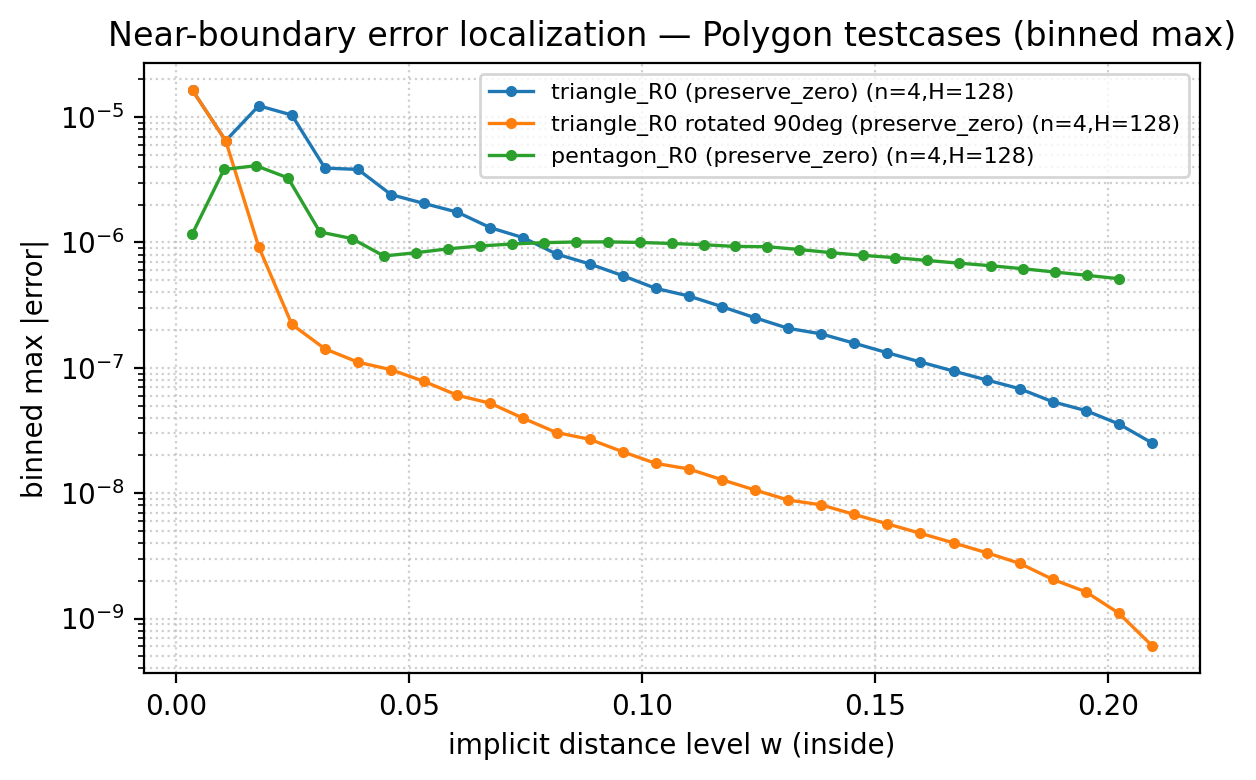

In [12]:
# %%
def _log_edges_with_zero(x: np.ndarray, n_bins: int, x_max: Optional[float] = None) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64).ravel()
    x = x[np.isfinite(x) & (x >= 0)]
    if x.size == 0:
        return np.array([0.0, 1.0], dtype=np.float64)
    if x_max is None:
        x_max = float(np.quantile(x, 0.995))
    x_max = max(float(x_max), 1e-12)
    pos = x[x > 0]
    if pos.size == 0:
        return np.linspace(0.0, x_max, int(n_bins) + 1)
    x_min = float(np.min(pos))
    if pos.size > 25:
        x_min = float(np.quantile(pos, 0.001))
    x_min = max(x_min, x_max * 1e-8, 1e-15)
    edges_pos = np.geomspace(x_min, x_max, int(n_bins))
    return np.concatenate([[0.0], edges_pos])


def compute_near_boundary_binning_with_max(
    w_inside: np.ndarray,
    err_inside: np.ndarray,
    n_bins: int = 30,
    w_max: Optional[float] = None,
    bin_scale: str = "log",
    samples_per_bin: Optional[int] = 500,
    seed: int = 0,
    max_from_full_bin: bool = True,
 ) -> pd.DataFrame:
    """Bin near-boundary samples by implicit level w and compute mean+max error per bin."""
    w_inside = np.asarray(w_inside, dtype=np.float64).ravel()
    err_inside = np.asarray(err_inside, dtype=np.float64).ravel()

    mask = np.isfinite(w_inside) & np.isfinite(err_inside) & (w_inside >= 0)
    w_inside = w_inside[mask]
    err_inside = err_inside[mask]

    if w_inside.size == 0:
        return pd.DataFrame({"w_mid": [], "err_mean": [], "err_max": [], "count": []})

    scale = str(bin_scale).strip().lower()
    if scale == "log":
        edges = _log_edges_with_zero(w_inside, int(n_bins), x_max=w_max)
    else:
        if w_max is None:
            w_max = float(np.quantile(w_inside, 0.995))
        w_max = max(float(w_max), 1e-12)
        edges = np.linspace(0.0, w_max, int(n_bins) + 1)

    rng = np.random.default_rng(int(seed))
    rows = []
    for i in range(int(n_bins)):
        a, b = float(edges[i]), float(edges[i + 1])
        sel = (w_inside >= a) & (w_inside < b)
        if not np.any(sel):
            continue
        idx_full = np.flatnonzero(sel)
        idx_mean = idx_full
        if samples_per_bin is not None and idx_full.size > int(samples_per_bin):
            idx_mean = rng.choice(idx_full, size=int(samples_per_bin), replace=False)
        if scale == "log" and a > 0 and b > 0:
            w_mid = float(np.sqrt(a * b))
        else:
            w_mid = 0.5 * (a + b)
        w_mid = max(w_mid, 1e-300)
        err_mean = float(np.mean(err_inside[idx_mean]))
        if max_from_full_bin:
            err_max = float(np.max(err_inside[idx_full]))
        else:
            err_max = float(np.max(err_inside[idx_mean]))
        rows.append(
            {
                "w_mid": w_mid,
                "err_mean": err_mean,
                "err_max": err_max,
                "count": int(idx_full.size),
            }
        )

    return pd.DataFrame(rows)


def plot_near_boundary_max_curves(names: List[str], title: str):
    bin_dfs = []
    labels = []
    for name in names:
        res = all_results[(name, n_show, H_show)]
        w_inside = res["wP"][res["inside"]]
        err_inside = res["err"][res["inside"]]
        df = compute_near_boundary_binning_with_max(
            w_inside=w_inside,
            err_inside=err_inside,
            n_bins=30,
            bin_scale="log",
            samples_per_bin=500,
            seed=0,
            max_from_full_bin=True,
        )
        bin_dfs.append(df)
        labels.append(f"{name} (n={n_show},H={H_show})")

    fig, ax = plt.subplots(figsize=(6.2, 4.0))
    for df, lab in zip(bin_dfs, labels):
        if df.empty:
            continue
        ax.plot(df["w_mid"], df["err_max"], marker="o", ms=3, lw=1.2, label=lab)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("implicit distance level w (inside)")
    ax.set_ylabel("binned max |error|")
    ax.grid(True, which="both", ls=":", alpha=0.6)
    ax.set_title(title)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


names = [
    "triangle_R0 (preserve_zero)",
    "triangle_R0 rotated 90deg (preserve_zero)",
    "pentagon_R0 (preserve_zero)",
]
plot_near_boundary_max_curves(names, title="Near-boundary error localization — Polygon testcases (binned max; log bins)")

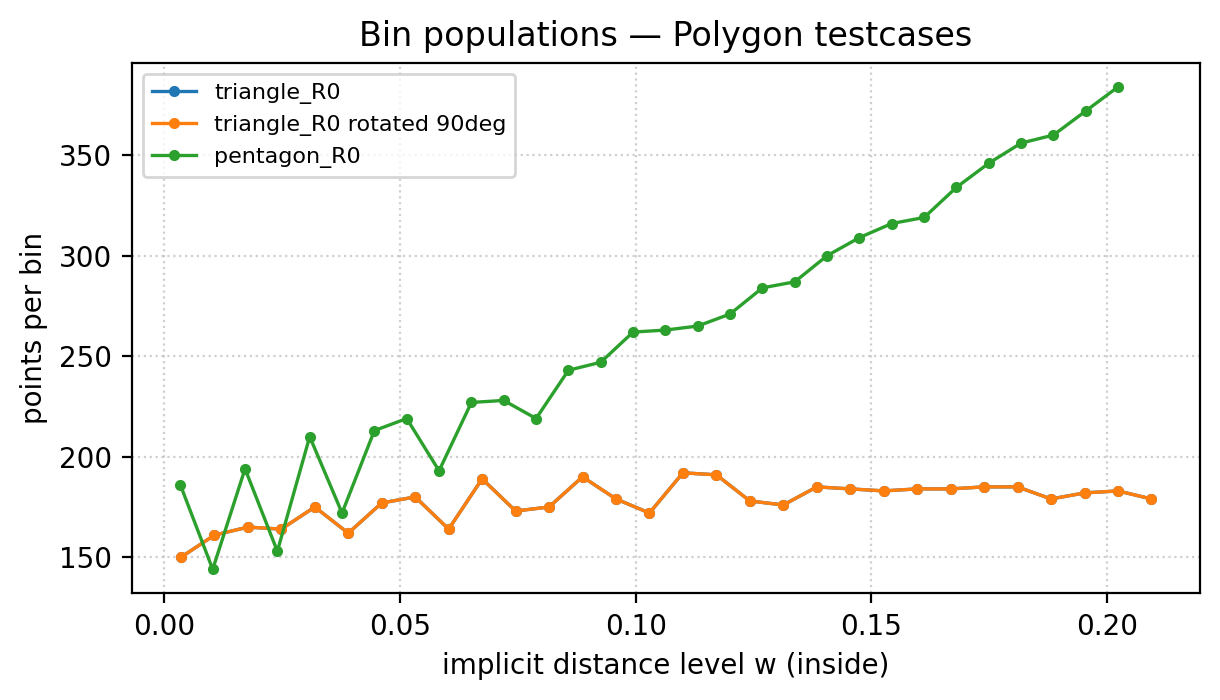

Whole-domain mean vs weighted-from-bins (using the plotted bins):
  triangle_R0 (preserve_zero): mean=1.117995e-07 | weighted_bins=1.123177e-07 | covered=0.995
  triangle_R0 rotated 90deg (preserve_zero): mean=1.240424e-08 | weighted_bins=1.246606e-08 | covered=0.995
  pentagon_R0 (preserve_zero): mean=3.762484e-07 | weighted_bins=3.757635e-07 | covered=0.995


In [13]:
# %%
def _weighted_mean_from_bins(df: pd.DataFrame) -> float:
    if df is None or df.empty:
        return float("nan")
    if "count" not in df.columns or "err_mean" not in df.columns:
        return float("nan")
    w = np.asarray(df["count"], dtype=np.float64)
    v = np.asarray(df["err_mean"], dtype=np.float64)
    s = float(np.sum(w))
    if s <= 0:
        return float("nan")
    return float(np.sum(w * v) / s)


def plot_bin_counts(bin_dfs: List[pd.DataFrame], labels: List[str], title: str):
    fig, ax = plt.subplots(figsize=(6.2, 3.6))
    for df, lab in zip(bin_dfs, labels):
        if df is None or df.empty or "count" not in df.columns:
            continue
        ax.plot(df["w_mid"], df["count"], marker="o", ms=3, lw=1.2, label=lab)
    ax.set_xlabel("implicit distance level w (inside)")
    ax.set_ylabel("points per bin")
    ax.grid(True, which="both", ls=":", alpha=0.6)
    ax.set_title(title)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


# Reuse the same bins used by the binned-mean plot from Cell 1 (bin_dfs, labels).
plot_bin_counts(bin_dfs, labels, title="Bin populations — Polygon testcases")

# Sanity check: compare whole-domain mean to weighted mean reconstructed from bins.
print("Whole-domain mean vs weighted-from-bins (using the plotted bins):")
for name, df in zip(names, bin_dfs):
    res = all_results[(name, n_show, H_show)]
    overall_mean = float(np.mean(res["err"][res["inside"]]))
    binned_weighted_mean = _weighted_mean_from_bins(df)
    total_inside = int(np.sum(res["inside"]))
    total_in_bins = int(np.sum(df["count"])) if (df is not None and not df.empty and "count" in df.columns) else 0
    frac = (total_in_bins / total_inside) if total_inside > 0 else float("nan")
    print(f"  {name}: mean={overall_mean:.6e} | weighted_bins={binned_weighted_mean:.6e} | covered={frac:.3f}")